In [1]:
# load the file merged_results_enriched_and_modified

import pandas as pd
from itables import init_notebook_mode, show

# Initialize itables - makes all DataFrames interactive in HTML export
init_notebook_mode(all_interactive=True)

df = pd.read_csv("merged_results_enriched_and_modified.csv")

df[["PathBoostAccuracy_times 100", 'PathBoostAccuracy_times_100']].max(axis=1)
df['PB_accuracy'] = df['PB_accuracy'] * 100
df['PathBoostAccuracy_times 100'] = df[
    ["PathBoostAccuracy_times 100", 'PathBoostAccuracy_times_100', 'PB_accuracy']].max(axis=1)
print(len(df))
df = df.loc[df['PathBoostAccuracy_times 100'] >= 1]

# remove all the negative values
def remove_neg_value(x):
    try:
        if x < 0:
            return None
        else:
            return x
    except:
        return x

df =  df.map(remove_neg_value)




69


In [2]:
# Create df_results for use in subsequent analysis cells
df_results = df.copy()

# Calculate majority class percentage for filtering balanced datasets
if 'n_graphs_firs_class' in df_results.columns and 'Graphs' in df_results.columns:
    df_results['fist_class_percentage'] = (df_results['n_graphs_firs_class'] / df_results['Graphs']) * 100
elif 'ClassPercentages' in df_results.columns:
    # Extract first percentage from ClassPercentages string if available
    df_results['fist_class_percentage'] = df_results['ClassPercentages'].apply(
        lambda x: float(str(x).split('/')[0]) if pd.notna(x) and '/' in str(x) else 50
    )

print(f"df_results created with {len(df_results)} rows")
print(f"Columns: {list(df_results.columns)[:10]}...")  # Show first 10 columns

df_results created with 52 rows
Columns: ['Dataset', 'Graphs', 'AvgNodes', 'AvgEdges', 'NodeFeatures', 'EdgeFeatures', 'TotalFeatures', 'ClassPercentages', 'CatAttrClasses', 'PathBoostAccuracy_times 100']...


# CSV Results Analysis

This notebook analyzes the merged benchmark results to compare **PathBoost** against other graph classification methods (GNN, Graph Kernels).

## Goals
- Identify datasets where PathBoost outperforms other methods
- Filter results by class balance to focus on meaningful comparisons
- Export formatted tables for publication/reporting

## Data Source
The input file `merged_results_enriched_and_modified.csv` contains:
- Dataset metadata (size, features, class distribution)
- Accuracy results from PathBoost, GNN, and various graph kernels
- Standard deviations from 10×10 cross-validation

---

## 1. Load and Clean Data

Load the merged results and handle data quality issues:
- Consolidate PathBoost accuracy columns (different naming conventions)
- Remove invalid negative values
- Filter out entries with missing PathBoost results

In [3]:
# Get all accuracy columns (excluding PathBoost and std columns)
acc_columns = [col for col in df_results.columns
               if 'accuracy' in col.lower()
               and 'std' not in col.lower()
               and col != 'PathBoostAccuracy_times 100']

# Create difference columns: PathBoost - other method
for col in acc_columns:
    diff_col_name = f'PB_diff_{col}'
    df_results[diff_col_name] = df_results['PathBoostAccuracy_times 100'] - df_results[col]

df_results

Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## 2. Identify Best-Performing Datasets for PathBoost

Find datasets where PathBoost achieves the **highest accuracy** compared to all other methods.


In [4]:
# get columns that refers to accuracy
columns = df.columns
acc_columns = [col for col in columns if ("acc" in col.lower()) and "std" not in col.lower()]
acc_columns
# get the datasets where path boost perform the best (columns "PathBoostAccuracy_times 100")

ac_df = df[acc_columns]  # acccuracy dataset

best_performances_dataset = ac_df.loc[ac_df["PathBoostAccuracy_times 100"] >= ac_df.max(axis=1)]

best_performances_dataset = df.loc[best_performances_dataset.index]
best_performances_dataset[["Dataset", "n_graphs_firs_class"]]


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## 3. Filter by Class Balance Threshold

Highly imbalanced datasets (e.g., 95%/5% class split) can yield misleadingly high accuracy scores—a trivial classifier predicting the majority class would score 95%.

**Filtering criteria:** Keep only datasets where the majority class is below the threshold (default: 85%).



## 4. Define Columns for Export



In [5]:

columns_extended = [
    "Dataset",
    "Graphs",
    "AvgNodes",
    "AvgEdges",
    "NodeFeatures",
    "EdgeFeatures",
    "TotalFeatures",
    "ClassPercentages",
    "CatAttrClasses",
    "PathBoostAccuracy_times 100",
    "PathBoostAccuracy",
    "PathBoostStd10",
    "PathBoostStd100",
    "GNNAccuracy",
    "GNNStd10",
    "GNNStd100",
    "KernelAccuracy",
    "source_file",
    "source_file_dup",
    "PathBoostAccuracy_times_100",
    "Weisfeiler-Lehman subtree kernel_accuracy",
    "Weisfeiler-Lehman subtree kernel_std_10",
    "Weisfeiler-Lehman subtree kernel_std_100",
    "Weisfeiler-Lehman subtree kernel linear_accuracy",
    "Weisfeiler-Lehman subtree kernel linear_std_10",
    "Weisfeiler-Lehman subtree kernel linear_std_100",
    "Graphlet kernel_accuracy",
    "Graphlet kernel_std_10",
    "Graphlet kernel_std_100",
    "Graphlet kernel linear_accuracy",
    "Graphlet kernel linear_std_10",
    "Graphlet kernel linear_std_100",
    "Shortest-path kernel_accuracy",
    "Shortest-path kernel_std_10",
    "Shortest-path kernel_std_100",
    "Shortest-path kernel linear_accuracy",
    "Shortest-path kernel linear_std_10",
    "Shortest-path kernel linear_std_100",
    "Weisfeiler-Lehman optimal assignment kernel_accuracy",
    "Weisfeiler-Lehman optimal assignment kernel_std_10",
    "Weisfeiler-Lehman optimal assignment kernel_std_100",
    "GNN_accuracy",
    "GNN_accuracy_std10",
    "GNN_accuracy_std100",
    "GNN_balanced_accuracy",
    "GNN_balanced_accuracy_std10",
    "GNN_balanced_accuracy_std100",
    "GNN_f1",
    "GNN_f1_macro",
    "GNN_f1_macro_std10",
    "GNN_f1_macro_std100",
    "GNN_f1_std10",
    "GNN_f1_std100",
    "GNN_recall",
    "GNN_recall_std10",
    "GNN_recall_std100",
    "GNN_roc_auc",
       "GNN_roc_auc_std10",
    "GNN_roc_auc_std100",
    "PB_accuracy",
    "PB_accuracy_std10",
    "PB_accuracy_std100",
    "PB_balanced_accuracy",
    "PB_balanced_accuracy_std10",
    "PB_balanced_accuracy_std100",
    "PB_f1",
    "PB_f1_macro",
    "PB_f1_macro_std10",
    "PB_f1_macro_std100",
    "PB_f1_std10",
    "PB_f1_std100",
    "PB_recall",
    "PB_recall_std10",
    "PB_recall_std100"
]



columns_extended = [
    "Dataset",
    "PathBoostAccuracy_times 100",
    "PathBoostStd10",
    "GNNAccuracy",
    "GNNStd10",
    "Weisfeiler-Lehman subtree kernel_accuracy",
    "Weisfeiler-Lehman subtree kernel_std_10",
    "Weisfeiler-Lehman subtree kernel linear_accuracy",
    "Weisfeiler-Lehman subtree kernel linear_std_10",
    "Graphlet kernel_accuracy",
    "Graphlet kernel_std_10",
    "Graphlet kernel linear_accuracy",
    "Graphlet kernel linear_std_10",
    "Shortest-path kernel_accuracy",
    "Shortest-path kernel_std_10",
    "Shortest-path kernel linear_accuracy",
    "Shortest-path kernel linear_std_10",
    "GNN_f1",
    "GNN_f1_std10",
    "GNN_f1_macro",
    "GNN_f1_macro_std10",
    "PB_f1_macro",
    "PB_f1_macro_std10",
    "PB_f1",
    "PB_f1_std10",

]


columns_to_multiply = [
    "PathBoostStd10",
    "GNN_f1",
    "GNN_f1_std10",
    "GNN_f1_macro",
    "GNN_f1_macro_std10",
    "PB_f1_macro",
    "PB_f1_macro_std10",
    "PB_f1",
    "PB_f1_std10"
]

pairwise_col = [
("PathBoostAccuracy_times 100",
    "PathBoostStd10"),
("GNNAccuracy",
    "GNNStd10"),

]

## 5. Format and Export Results

Prepare publication-ready output:

1. **Filter** to balanced datasets only (majority class < 85%)
2. **Scale** decimal columns to percentages (×100)
3. **Round** all values to 2 decimal places
4. **Format** as "mean ± std" for each metric pair
5. **Export** to CSV for use in papers/reports

Output: `pathboost_best_performing_datasets_under_85_percent.csv`

## 6. Correlation Analysis

Check correlation with pathboost accuracy
Explore which dataset characteristics correlate with PathBoost performance.


In [6]:
# check correlation

numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

filtered_columns = [col for col in numeric_columns if 'std' not in col.lower()]
df[filtered_columns].corr()['PathBoostAccuracy_times 100']



Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## 7. Prepare Comparison Data

Filter to balanced datasets and prepare columns for systematic comparison:
- Keep datasets where majority class < 85% (meaningful accuracy metric)
- Compute best kernel accuracy across all kernel methods
- Normalize GNN accuracy to 0-100 scale
- Create explicit difference columns for PathBoost vs competitors

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to balanced datasets (majority class < 85%)
df_balanced = df_results[df_results['fist_class_percentage'] < 85].copy()

# Identify kernel accuracy columns
kernel_acc_cols = [col for col in df_balanced.columns 
                   if 'kernel' in col.lower() and 'accuracy' in col.lower() and 'std' not in col.lower()]


# Compute BestKernel_accuracy (max across all kernel methods per row)
df_balanced['BestKernel_accuracy'] = df_balanced[kernel_acc_cols].max(axis=1)

# Normalize GNN accuracy to 0-100 scale (check if GNN_accuracy exists and is in decimal form)
if 'GNN_accuracy' in df_balanced.columns:
    # Use GNN_accuracy * 100 if it's in decimal form, otherwise use GNNAccuracy
    df_balanced['GNN_accuracy_100'] = df_balanced['GNN_accuracy'].apply(
        lambda x: x * 100 if pd.notna(x) and x <= 1 else x
    )
    # Fill missing values with GNNAccuracy if available
    if 'GNNAccuracy' in df_balanced.columns:
        df_balanced['GNN_accuracy_100'] = df_balanced['GNN_accuracy_100'].fillna(df_balanced['GNNAccuracy'])
else:
    df_balanced['GNN_accuracy_100'] = df_balanced['GNNAccuracy']

# Create explicit difference columns
df_balanced['PB_minus_GNN_accuracy'] = df_balanced['PathBoostAccuracy_times 100'] - df_balanced['GNN_accuracy_100']
df_balanced['PB_minus_BestKernel_accuracy'] = df_balanced['PathBoostAccuracy_times 100'] - df_balanced['BestKernel_accuracy']

# F1 macro comparison (scale to 0-100)
if 'PB_f1_macro' in df_balanced.columns and 'GNN_f1_macro' in df_balanced.columns:
    df_balanced['PB_f1_macro_100'] = df_balanced['PB_f1_macro'] * 100
    df_balanced['GNN_f1_macro_100'] = df_balanced['GNN_f1_macro'] * 100
    df_balanced['PB_minus_GNN_f1_macro'] = df_balanced['PB_f1_macro_100'] - df_balanced['GNN_f1_macro_100']



# Preview the comparison columns
comparison_cols = ['Dataset', 'PathBoostAccuracy_times 100', 'GNN_accuracy_100', 'BestKernel_accuracy',
                   'PB_minus_GNN_accuracy', 'PB_minus_BestKernel_accuracy']


### 7.1 All Datasets Performance Table

Full results for **all** evaluated datasets (no class-balance filter).
`---` indicates PathBoost was skipped (no categorical node attributes or non-binary labels),
GNN/Kernel was not evaluated, or timed out.
$\dagger$ marks datasets where the majority class exceeds 85 % (accuracy is a misleading metric for these).

In [ ]:
# 7.1 All Datasets Performance Table (no class-balance filter)
import numpy as np

df_all = df_results.copy()

# --- Fix sentinel values (-1, -100) → NaN ---------------------------------
_sentinel = [-1, -100]
for col in df_all.select_dtypes(include=[float, int]).columns:
    df_all[col] = df_all[col].replace(_sentinel, np.nan)

# PB accuracy = 0 means FAILED / skipped → NaN
df_all['PB_acc_100'] = df_all['PathBoostAccuracy_times 100'].apply(
    lambda x: np.nan if (pd.notna(x) and x <= 0) else x)
df_all['PB_std10_100'] = df_all['PathBoostStd10'] * 100   # decimal → %

# GNN accuracy (already in %)
if 'GNN_accuracy' in df_all.columns:
    df_all['GNN_accuracy_100'] = df_all['GNN_accuracy'].apply(
        lambda x: x * 100 if pd.notna(x) and x <= 1 else x)
    df_all['GNN_accuracy_100'] = df_all['GNN_accuracy_100'].fillna(df_all.get('GNNAccuracy'))
else:
    df_all['GNN_accuracy_100'] = df_all.get('GNNAccuracy')
df_all['GNN_std10_100'] = df_all.get('GNNStd10')   # already in %

# Best kernel per row
_kern_acc_cols = [c for c in df_all.columns
                  if 'kernel' in c.lower() and 'accuracy' in c.lower()
                  and 'std' not in c.lower() and c != 'KernelAccuracy']
df_all['BestKernel_accuracy'] = df_all[_kern_acc_cols].max(axis=1)

def _best_kernel_std(row):
    best_val, best_std = -np.inf, np.nan
    for ac in _kern_acc_cols:
        sc = ac.replace('_accuracy', '_std_10')
        v = row.get(ac, np.nan)
        if pd.notna(v) and v > best_val:
            best_val, best_std = v, row.get(sc, np.nan)
    return best_std

df_all['BestKernel_std10'] = df_all.apply(_best_kernel_std, axis=1)

# F1-macro (scale 0-1 → %)
for src, dst in [('PB_f1_macro', 'PB_f1_macro_100'),
                 ('PB_f1_macro_std10', 'PB_f1_macro_std10_100'),
                 ('GNN_f1_macro', 'GNN_f1_macro_100'),
                 ('GNN_f1_macro_std10', 'GNN_f1_macro_std10_100')]:
    if src in df_all.columns:
        df_all[dst] = df_all[src].apply(
            lambda x: x * 100 if pd.notna(x) and 0 < x <= 1 else np.nan)
    else:
        df_all[dst] = np.nan

# Imbalanced flag
def _imbalanced(row):
    fcp = row.get('fist_class_percentage', np.nan)
    if pd.isna(fcp):
        return False
    return fcp >= 85 or fcp <= 15

df_all['imbalanced'] = df_all.apply(_imbalanced, axis=1)

# --- Build display table --------------------------------------------------
def _fmt(mean, std):
    if pd.isna(mean):
        return '---'
    if pd.isna(std) or std == 0:
        return f'{mean:.2f}'
    return f'{mean:.2f} ± {std:.2f}'

display_rows = []
for _, row in df_all.sort_values('Dataset').iterrows():
    flag = ' †' if row['imbalanced'] else ''
    display_rows.append({
        'Dataset': row['Dataset'] + flag,
        'PB Acc. (%)': _fmt(row['PB_acc_100'], row['PB_std10_100']),
        'GNN Acc. (%)': _fmt(row['GNN_accuracy_100'], row['GNN_std10_100']),
        'Best Kernel Acc. (%)': _fmt(row['BestKernel_accuracy'], row['BestKernel_std10']),
        'PB F1-Macro (%)': _fmt(row.get('PB_f1_macro_100'), row.get('PB_f1_macro_std10_100')),
        'GNN F1-Macro (%)': _fmt(row.get('GNN_f1_macro_100'), row.get('GNN_f1_macro_std10_100')),
    })

df_display_all = pd.DataFrame(display_rows).set_index('Dataset')

print(f"All datasets: {len(df_all)} total  |  "
      f"balanced (majority < 85%): {(~df_all['imbalanced']).sum()}  |  "
      f"imbalanced †: {df_all['imbalanced'].sum()}")
print("† = majority class ≥ 85% (accuracy is misleading)\n")

from itables import show
show(df_display_all, caption="All datasets — PathBoost vs GNN vs Best Kernel")

## 8. Performance Comparison Visualizations

Visual comparison of PathBoost against GNN and best kernel methods.

### 8.1 Bar Chart - Mean Accuracy

Compare overall performance across algorithms on balanced datasets.

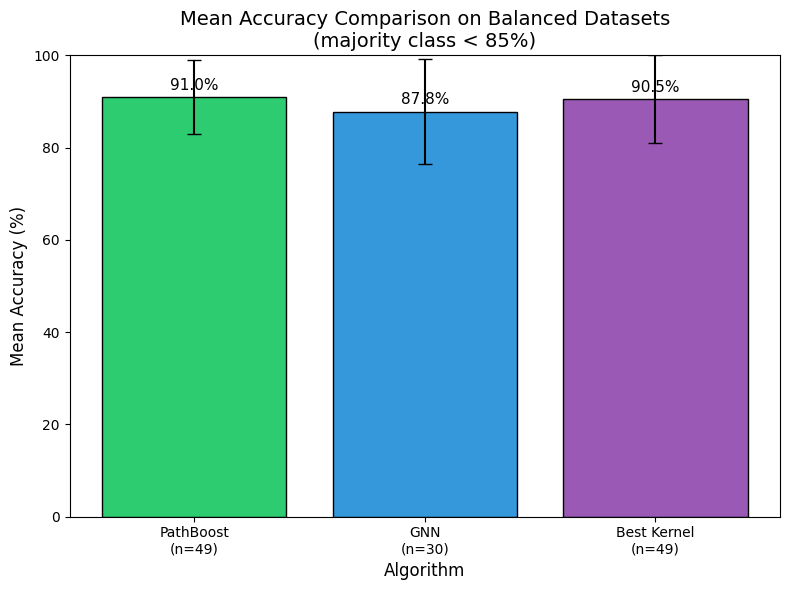


Summary Statistics:
  PathBoost: mean=90.99%, std=8.01%, n=49
  GNN: mean=87.79%, std=11.33%, n=30
  Best Kernel: mean=90.49%, std=9.47%, n=49


In [8]:
# 8.1 Bar Chart - Mean Accuracy Comparison
# Calculate mean and std for each algorithm (only where values exist)

algorithms = {
    'PathBoost': 'PathBoostAccuracy_times 100',
    'GNN': 'GNN_accuracy_100',
    'Best Kernel': 'BestKernel_accuracy'
}

means = []
stds = []
labels = []

for name, col in algorithms.items():
    if col in df_balanced.columns:
        valid_data = df_balanced[col].dropna()
        if len(valid_data) > 0:
            means.append(valid_data.mean())
            stds.append(valid_data.std())
            labels.append(f"{name}\n(n={len(valid_data)})")

# Create bar chart
fig, ax = plt.subplots(figsize=(8, 6))
x_pos = np.arange(len(labels))
bars = ax.bar(x_pos, means, yerr=stds, capsize=5, color=['#2ecc71', '#3498db', '#9b59b6'], edgecolor='black')

ax.set_ylabel('Mean Accuracy (%)', fontsize=12)
ax.set_xlabel('Algorithm', fontsize=12)
ax.set_title('Mean Accuracy Comparison on Balanced Datasets\n(majority class < 85%)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylim([0, 100])

# Add value labels on bars
for bar, mean, std in zip(bars, means, stds):
    height = bar.get_height()
    ax.annotate(f'{mean:.1f}%',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Print summary stats
print("\nSummary Statistics:")
for name, col in algorithms.items():
    if col in df_balanced.columns:
        valid_data = df_balanced[col].dropna()
        if len(valid_data) > 0:
            print(f"  {name}: mean={valid_data.mean():.2f}%, std={valid_data.std():.2f}%, n={len(valid_data)}")

### 8.2 Scatter Plots - Pairwise Comparison

Scatter plots showing per-dataset comparison. Points above the diagonal indicate PathBoost wins.

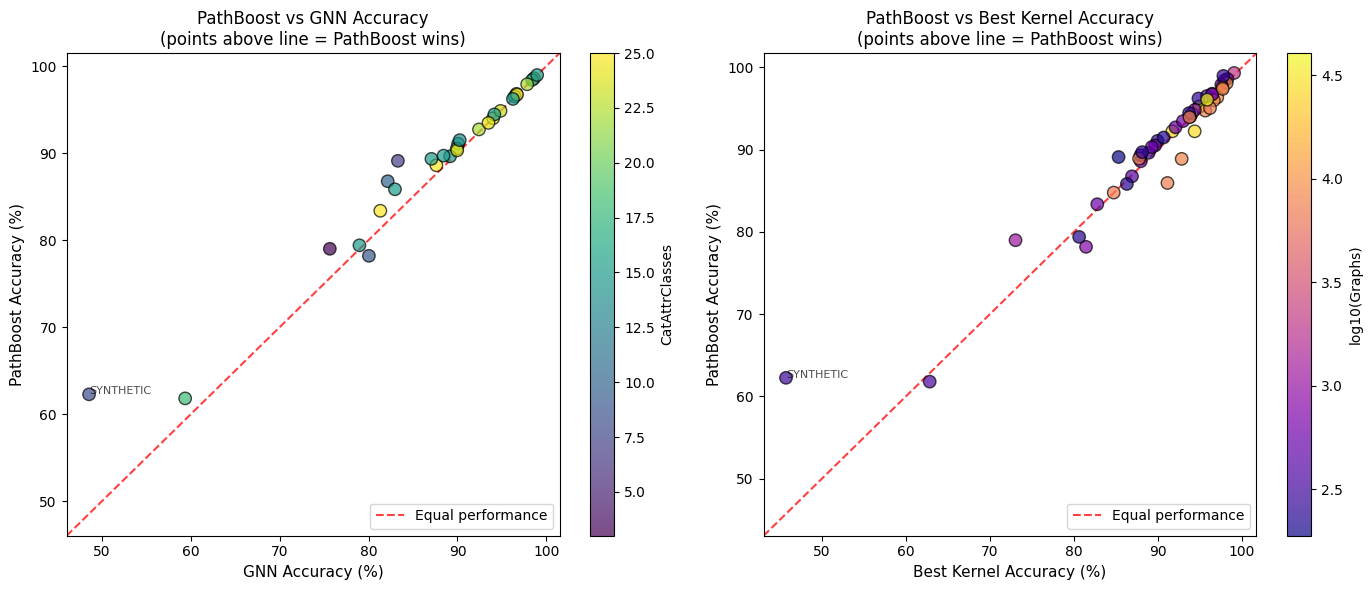

In [9]:
# 8.2 Scatter Plots - PathBoost vs GNN and PathBoost vs Best Kernel

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot 1: PathBoost vs GNN
ax1 = axes[0]
df_scatter1 = df_balanced[['PathBoostAccuracy_times 100', 'GNN_accuracy_100', 'CatAttrClasses', 'Dataset']].dropna()
scatter1 = ax1.scatter(df_scatter1['GNN_accuracy_100'], 
                       df_scatter1['PathBoostAccuracy_times 100'],
                       c=df_scatter1['CatAttrClasses'], 
                       cmap='viridis', s=80, alpha=0.7, edgecolors='black')
# Diagonal reference line
lims = [min(ax1.get_xlim()[0], ax1.get_ylim()[0]), max(ax1.get_xlim()[1], ax1.get_ylim()[1])]
ax1.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Equal performance')
ax1.set_xlim(lims)
ax1.set_ylim(lims)
ax1.set_xlabel('GNN Accuracy (%)', fontsize=11)
ax1.set_ylabel('PathBoost Accuracy (%)', fontsize=11)
ax1.set_title('PathBoost vs GNN Accuracy\n(points above line = PathBoost wins)', fontsize=12)
ax1.legend(loc='lower right')
plt.colorbar(scatter1, ax=ax1, label='CatAttrClasses')

# Annotate some datasets
for idx, row in df_scatter1.iterrows():
    if abs(row['PathBoostAccuracy_times 100'] - row['GNN_accuracy_100']) > 8:
        ax1.annotate(row['Dataset'], (row['GNN_accuracy_100'], row['PathBoostAccuracy_times 100']),
                    fontsize=8, alpha=0.7)

# Scatter plot 2: PathBoost vs Best Kernel
ax2 = axes[1]
df_scatter2 = df_balanced[['PathBoostAccuracy_times 100', 'BestKernel_accuracy', 'Graphs', 'Dataset']].dropna()
scatter2 = ax2.scatter(df_scatter2['BestKernel_accuracy'], 
                       df_scatter2['PathBoostAccuracy_times 100'],
                       c=np.log10(df_scatter2['Graphs']), 
                       cmap='plasma', s=80, alpha=0.7, edgecolors='black')
# Diagonal reference line
lims2 = [min(ax2.get_xlim()[0], ax2.get_ylim()[0]), max(ax2.get_xlim()[1], ax2.get_ylim()[1])]
ax2.plot(lims2, lims2, 'r--', alpha=0.75, zorder=0, label='Equal performance')
ax2.set_xlim(lims2)
ax2.set_ylim(lims2)
ax2.set_xlabel('Best Kernel Accuracy (%)', fontsize=11)
ax2.set_ylabel('PathBoost Accuracy (%)', fontsize=11)
ax2.set_title('PathBoost vs Best Kernel Accuracy\n(points above line = PathBoost wins)', fontsize=12)
ax2.legend(loc='lower right')
plt.colorbar(scatter2, ax=ax2, label='log10(Graphs)')

# Annotate some datasets
for idx, row in df_scatter2.iterrows():
    if abs(row['PathBoostAccuracy_times 100'] - row['BestKernel_accuracy']) > 8:
        ax2.annotate(row['Dataset'], (row['BestKernel_accuracy'], row['PathBoostAccuracy_times 100']),
                    fontsize=8, alpha=0.7)

plt.tight_layout()
plt.show()

### 8.3 Win/Loss Summary Table

Count datasets where PathBoost wins, loses, or ties (within 1% margin) against each competitor.

Win/Loss Summary (margin = 1%)

BALANCED DATASETS (majority class < 85%):



Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)



ALL DATASETS:



Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


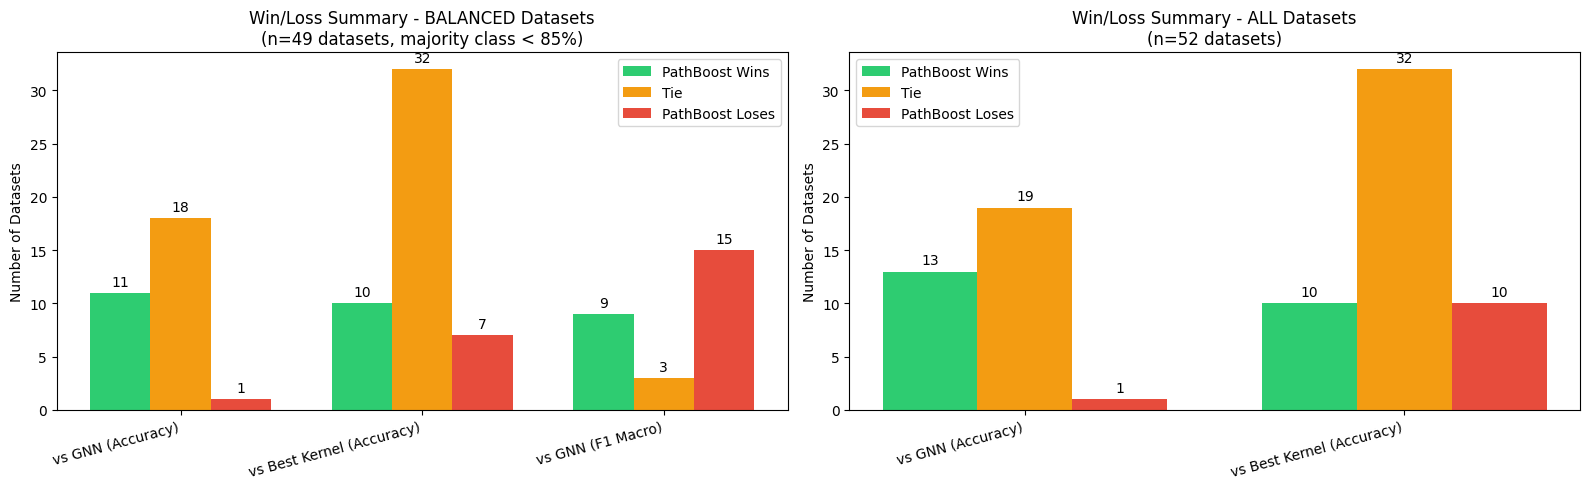


Datasets where PathBoost significantly outperforms GNN (>5% margin) - Balanced:


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


In [10]:
# 8.3 Win/Loss Summary Table
margin = 1.0  # 1% margin for "tie"

def count_wins(diff_series, margin=1.0):
    """Count wins, losses, ties based on difference column"""
    valid = diff_series.dropna()
    wins = (valid > margin).sum()
    losses = (valid < -margin).sum()
    ties = ((valid >= -margin) & (valid <= margin)).sum()
    return {'PathBoost Wins': wins, 'PathBoost Loses': losses, 'Tie (within 1%)': ties, 'Total': len(valid)}

# --- BALANCED DATASETS (majority class < 85%) ---
win_loss_data_balanced = {}
if 'PB_minus_GNN_accuracy' in df_balanced.columns:
    win_loss_data_balanced['vs GNN (Accuracy)'] = count_wins(df_balanced['PB_minus_GNN_accuracy'], margin)
if 'PB_minus_BestKernel_accuracy' in df_balanced.columns:
    win_loss_data_balanced['vs Best Kernel (Accuracy)'] = count_wins(df_balanced['PB_minus_BestKernel_accuracy'], margin)
if 'PB_minus_GNN_f1_macro' in df_balanced.columns:
    win_loss_data_balanced['vs GNN (F1 Macro)'] = count_wins(df_balanced['PB_minus_GNN_f1_macro'], margin)

# --- ALL DATASETS ---
# Create difference columns for all datasets (df_results)
df_all = df_results.copy()

# Create BestKernel_accuracy for all datasets
kernel_acc_cols_all = [col for col in df_all.columns 
                       if 'kernel' in col.lower() and 'accuracy' in col.lower() 
                       and 'std' not in col.lower() and 'diff' not in col.lower()]
if kernel_acc_cols_all:
    df_all['BestKernel_accuracy'] = df_all[kernel_acc_cols_all].max(axis=1)

# Create GNN_accuracy_100 for all datasets
if 'GNN_accuracy' in df_all.columns:
    df_all['GNN_accuracy_100'] = df_all['GNN_accuracy'].apply(
        lambda x: x * 100 if pd.notna(x) and x <= 1 else x
    )
    if 'GNNAccuracy' in df_all.columns:
        df_all['GNN_accuracy_100'] = df_all['GNN_accuracy_100'].fillna(df_all['GNNAccuracy'])
elif 'GNNAccuracy' in df_all.columns:
    df_all['GNN_accuracy_100'] = df_all['GNNAccuracy']

# Create difference columns for all datasets
df_all['PB_minus_GNN_accuracy'] = df_all['PathBoostAccuracy_times 100'] - df_all['GNN_accuracy_100']
df_all['PB_minus_BestKernel_accuracy'] = df_all['PathBoostAccuracy_times 100'] - df_all['BestKernel_accuracy']

win_loss_data_all = {}
if 'PB_minus_GNN_accuracy' in df_all.columns:
    win_loss_data_all['vs GNN (Accuracy)'] = count_wins(df_all['PB_minus_GNN_accuracy'], margin)
if 'PB_minus_BestKernel_accuracy' in df_all.columns:
    win_loss_data_all['vs Best Kernel (Accuracy)'] = count_wins(df_all['PB_minus_BestKernel_accuracy'], margin)

# Create DataFrames
win_loss_df_balanced = pd.DataFrame(win_loss_data_balanced).T
win_loss_df_all = pd.DataFrame(win_loss_data_all).T

print("Win/Loss Summary (margin = 1%)")
print("=" * 50)
print("\nBALANCED DATASETS (majority class < 85%):\n")
display(win_loss_df_balanced)
print("\nALL DATASETS:\n")
display(win_loss_df_all)

# Visual bar charts - side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Balanced datasets
ax1 = axes[0]
x = np.arange(len(win_loss_df_balanced))
width = 0.25

bars1 = ax1.bar(x - width, win_loss_df_balanced['PathBoost Wins'], width, label='PathBoost Wins', color='#2ecc71')
bars2 = ax1.bar(x, win_loss_df_balanced['Tie (within 1%)'], width, label='Tie', color='#f39c12')
bars3 = ax1.bar(x + width, win_loss_df_balanced['PathBoost Loses'], width, label='PathBoost Loses', color='#e74c3c')

ax1.set_ylabel('Number of Datasets')
ax1.set_title(f'Win/Loss Summary - BALANCED Datasets\n(n={len(df_balanced)} datasets, majority class < 85%)')
ax1.set_xticks(x)
ax1.set_xticklabels(win_loss_df_balanced.index, rotation=15, ha='right')
ax1.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

# Plot 2: All datasets
ax2 = axes[1]
x2 = np.arange(len(win_loss_df_all))

bars1 = ax2.bar(x2 - width, win_loss_df_all['PathBoost Wins'], width, label='PathBoost Wins', color='#2ecc71')
bars2 = ax2.bar(x2, win_loss_df_all['Tie (within 1%)'], width, label='Tie', color='#f39c12')
bars3 = ax2.bar(x2 + width, win_loss_df_all['PathBoost Loses'], width, label='PathBoost Loses', color='#e74c3c')

ax2.set_ylabel('Number of Datasets')
ax2.set_title(f'Win/Loss Summary - ALL Datasets\n(n={len(df_results)} datasets)')
ax2.set_xticks(x2)
ax2.set_xticklabels(win_loss_df_all.index, rotation=15, ha='right')
ax2.legend()

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# List datasets where PathBoost significantly outperforms
print("\nDatasets where PathBoost significantly outperforms GNN (>5% margin) - Balanced:")
if 'PB_minus_GNN_accuracy' in df_balanced.columns:
    significant_wins = df_balanced[df_balanced['PB_minus_GNN_accuracy'] > 5][['Dataset', 'PathBoostAccuracy_times 100', 'GNN_accuracy_100', 'PB_minus_GNN_accuracy']]
    if len(significant_wins) > 0:
        display(significant_wins.sort_values('PB_minus_GNN_accuracy', ascending=False))
    else:
        print("  None found.")

### 8.4 Statistical Significance Testing

Perform paired statistical tests to determine if PathBoost significantly outperforms other methods.

**Tests used:**
- **Paired t-test**: Assumes normal distribution of differences
- **Wilcoxon signed-rank test**: Non-parametric alternative (more robust)

**Interpretation:**
- p < 0.05: Statistically significant difference
- p < 0.01: Highly significant difference

In [11]:
# 8.4 Statistical Significance Testing - Per Dataset
from scipy.stats import t as t_dist

def compute_pvalue_from_means(mean1, std1, mean2, std2, n=100):
    """
    Compute p-value for difference between two means using Welch's t-test approximation.
    Assumes n=100 samples (10 repetitions x 10 folds).
    
    H0: mean1 = mean2
    H1: mean1 > mean2 (one-sided)
    """
    if pd.isna(mean1) or pd.isna(mean2) or pd.isna(std1) or pd.isna(std2):
        return np.nan
    
    mean1, std1, mean2, std2 = float(mean1), float(std1), float(mean2), float(std2)
    
    # Standard error of the difference
    se1 = std1 / np.sqrt(n)
    se2 = std2 / np.sqrt(n)
    se_diff = np.sqrt(se1**2 + se2**2)
    
    if se_diff == 0:
        return np.nan
    
    # t-statistic
    t_stat = (mean1 - mean2) / se_diff
    
    # Welch-Satterthwaite degrees of freedom
    if se1**2 + se2**2 > 0:
        df = (se1**2 + se2**2)**2 / (se1**4/(n-1) + se2**4/(n-1))
    else:
        df = n - 1
    
    # One-sided p-value (H1: mean1 > mean2)
    # Use sf() (survival function) instead of 1 - cdf() for numerical accuracy
    # when p-values are very small
    p_value = t_dist.sf(t_stat, df)
    
    return p_value

def significance_stars(p):
    """Convert p-value to significance stars"""
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

# Prepare data
df_test = df_results.copy()

# Ensure numeric types
for col in df_test.columns:
    if 'accuracy' in col.lower() or 'f1' in col.lower() or 'std' in col.lower():
        df_test[col] = pd.to_numeric(df_test[col], errors='coerce')

# Create results list
per_dataset_results = []

for idx, row in df_test.iterrows():
    dataset = row.get('Dataset', f'Dataset_{idx}')
    
    result = {'Dataset': dataset}
    
    # PathBoost accuracy
    pb_acc = row.get('PathBoostAccuracy_times 100', np.nan)
    pb_std = row.get('PathBoostStd10', row.get('PB_accuracy_std10', np.nan))
    if pd.notna(pb_std) and pb_std < 1:  # Scale if in decimal
        pb_std = pb_std * 100
    
    result['PB_Accuracy'] = pb_acc
    
    # GNN accuracy
    gnn_acc = row.get('GNN_accuracy', row.get('GNNAccuracy', np.nan))
    if pd.notna(gnn_acc) and gnn_acc <= 1:
        gnn_acc = gnn_acc * 100
    gnn_std = row.get('GNN_accuracy_std10', row.get('GNNStd10', np.nan))
    if pd.notna(gnn_std) and gnn_std < 1:
        gnn_std = gnn_std * 100
    
    result['GNN_Accuracy'] = gnn_acc
    
    # PB vs GNN p-value
    if pd.notna(pb_acc) and pd.notna(gnn_acc):
        pb_std_est = pb_std if pd.notna(pb_std) else 5.0
        gnn_std_est = gnn_std if pd.notna(gnn_std) else 5.0
        
        p_val = compute_pvalue_from_means(pb_acc, pb_std_est, gnn_acc, gnn_std_est, n=10)
        result['PB_vs_GNN_pvalue'] = p_val
        result['PB_vs_GNN_sig'] = significance_stars(p_val)
        result['PB_better_than_GNN'] = 'Yes' if (pd.notna(p_val) and p_val < 0.05) else ('No' if pd.notna(p_val) else '')
    else:
        result['PB_vs_GNN_pvalue'] = np.nan
        result['PB_vs_GNN_sig'] = ''
        result['PB_better_than_GNN'] = ''
    
    # Best Kernel accuracy
    kernel_cols = [c for c in row.index if 'kernel' in c.lower() and 'accuracy' in c.lower() and 'std' not in c.lower()]
    kernel_std_cols = [c for c in row.index if 'kernel' in c.lower() and 'std_10' in c.lower()]
    
    if kernel_cols:
        kernel_values = [row[c] for c in kernel_cols if pd.notna(row[c])]
        if kernel_values:
            best_kernel_acc = max(kernel_values)
            best_kernel_idx = kernel_values.index(best_kernel_acc)
            best_kernel_col = [c for c in kernel_cols if pd.notna(row[c])][best_kernel_idx]
            
            # Find corresponding std column
            best_kernel_std = np.nan
            for std_col in kernel_std_cols:
                if best_kernel_col.replace('_accuracy', '') in std_col:
                    best_kernel_std = row[std_col]
                    break
            
            result['BestKernel_Accuracy'] = best_kernel_acc
            
            pb_std_est = pb_std if pd.notna(pb_std) else 5.0
            kernel_std_est = best_kernel_std if pd.notna(best_kernel_std) else 5.0
            
            p_val = compute_pvalue_from_means(pb_acc, pb_std_est, best_kernel_acc, kernel_std_est, n=10)
            result['PB_vs_Kernel_pvalue'] = p_val
            result['PB_vs_Kernel_sig'] = significance_stars(p_val)
            result['PB_better_than_Kernel'] = 'Yes' if (pd.notna(p_val) and p_val < 0.05) else ('No' if pd.notna(p_val) else '')
        else:
            result['BestKernel_Accuracy'] = np.nan
            result['PB_vs_Kernel_pvalue'] = np.nan
            result['PB_vs_Kernel_sig'] = ''
            result['PB_better_than_Kernel'] = ''
    
    # F1 Macro comparison
    pb_f1 = row.get('PB_f1_macro', np.nan)
    if pd.notna(pb_f1) and pb_f1 <= 1:
        pb_f1 = pb_f1 * 100
    pb_f1_std = row.get('PB_f1_macro_std10', np.nan)
    if pd.notna(pb_f1_std) and pb_f1_std < 1:
        pb_f1_std = pb_f1_std * 100
    
    gnn_f1 = row.get('GNN_f1_macro', np.nan)
    if pd.notna(gnn_f1) and gnn_f1 <= 1:
        gnn_f1 = gnn_f1 * 100
    gnn_f1_std = row.get('GNN_f1_macro_std10', np.nan)
    if pd.notna(gnn_f1_std) and gnn_f1_std < 1:
        gnn_f1_std = gnn_f1_std * 100
    
    result['PB_F1_Macro'] = pb_f1
    result['GNN_F1_Macro'] = gnn_f1
    
    if pd.notna(pb_f1) and pd.notna(gnn_f1):
        pb_f1_std_est = pb_f1_std if pd.notna(pb_f1_std) else 5.0
        gnn_f1_std_est = gnn_f1_std if pd.notna(gnn_f1_std) else 5.0
        
        p_val = compute_pvalue_from_means(pb_f1, pb_f1_std_est, gnn_f1, gnn_f1_std_est, n=10)
        result['PB_vs_GNN_F1_pvalue'] = p_val
        result['PB_vs_GNN_F1_sig'] = significance_stars(p_val)
        result['PB_better_F1'] = 'Yes' if (pd.notna(p_val) and p_val < 0.05) else ('No' if pd.notna(p_val) else '')
    else:
        result['PB_vs_GNN_F1_pvalue'] = np.nan
        result['PB_vs_GNN_F1_sig'] = ''
        result['PB_better_F1'] = ''
    
    per_dataset_results.append(result)

# Create DataFrame
df_pvalues = pd.DataFrame(per_dataset_results)

# Display columns for accuracy comparison
acc_cols = ['Dataset', 'PB_Accuracy', 'GNN_Accuracy', 'PB_vs_GNN_pvalue', 'PB_vs_GNN_sig', 'PB_better_than_GNN',
            'BestKernel_Accuracy', 'PB_vs_Kernel_pvalue', 'PB_vs_Kernel_sig', 'PB_better_than_Kernel']
acc_cols = [c for c in acc_cols if c in df_pvalues.columns]

# Display columns for F1 comparison
f1_cols = ['Dataset', 'PB_F1_Macro', 'GNN_F1_Macro', 'PB_vs_GNN_F1_pvalue', 'PB_vs_GNN_F1_sig', 'PB_better_F1']
f1_cols = [c for c in f1_cols if c in df_pvalues.columns]

print("=" * 100)
print("PER-DATASET STATISTICAL SIGNIFICANCE (Welch's t-test, one-sided: H1: PathBoost > Other)")
print("=" * 100)
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")
print("Note: p-values computed using std from 10-fold CV means\n")

print("-" * 100)
print("ACCURACY COMPARISON:")
print("-" * 100)
display(df_pvalues[acc_cols].round(4))

print("\n" + "-" * 100)
print("F1 MACRO COMPARISON:")
print("-" * 100)
display(df_pvalues[f1_cols].round(4))

# Summary counts
print("\n" + "=" * 100)
print("SUMMARY:")
print("=" * 100)
n_sig_gnn = (df_pvalues['PB_better_than_GNN'] == 'Yes').sum()
n_total_gnn = (df_pvalues['PB_vs_GNN_pvalue'].notna()).sum()
print(f"PathBoost significantly better than GNN (Accuracy): {n_sig_gnn}/{n_total_gnn} datasets")

if 'PB_better_than_Kernel' in df_pvalues.columns:
    n_sig_kernel = (df_pvalues['PB_better_than_Kernel'] == 'Yes').sum()
    n_total_kernel = (df_pvalues['PB_vs_Kernel_pvalue'].notna()).sum()
    print(f"PathBoost significantly better than Best Kernel (Accuracy): {n_sig_kernel}/{n_total_kernel} datasets")

if 'PB_better_F1' in df_pvalues.columns:
    n_sig_f1 = (df_pvalues['PB_better_F1'] == 'Yes').sum()
    n_total_f1 = (df_pvalues['PB_vs_GNN_F1_pvalue'].notna()).sum()
    print(f"PathBoost significantly better than GNN (F1 Macro): {n_sig_f1}/{n_total_f1} datasets")

PER-DATASET STATISTICAL SIGNIFICANCE (Welch's t-test, one-sided: H1: PathBoost > Other)

Significance: *** p<0.001, ** p<0.01, * p<0.05
Note: p-values computed using std from 10-fold CV means

----------------------------------------------------------------------------------------------------
ACCURACY COMPARISON:
----------------------------------------------------------------------------------------------------


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)



----------------------------------------------------------------------------------------------------
F1 MACRO COMPARISON:
----------------------------------------------------------------------------------------------------


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)



SUMMARY:
PathBoost significantly better than GNN (Accuracy): 16/31 datasets
PathBoost significantly better than Best Kernel (Accuracy): 33/52 datasets
PathBoost significantly better than GNN (F1 Macro): 6/27 datasets


In [12]:
# 8.5 P-value Table - Selected Datasets (Ordered)

selected_datasets = [
    'AIDS',
    'BZR',
    'DHFR',
    'MUTAG',
    'PROTEINS_full',
    'PTC_FM',
    'SYNTHETIC',
    'Tox21_ARE_evaluation',
    'Tox21_ARE_testing',
    'Tox21_ARE_training',
    'Tox21_MMP_testing',
    'Tox21_MMP_training',
]

# Match dataset names (handle slight naming differences)
def match_dataset(name, available):
    """Find the best match for a dataset name"""
    if name in available:
        return name
    # Try partial matching
    for avail in available:
        if name.lower().replace('_', '') in avail.lower().replace('_', ''):
            return avail
        if avail.lower().replace('_', '') in name.lower().replace('_', ''):
            return avail
    return name  # return original if no match

available_datasets = df_pvalues['Dataset'].tolist()
matched_datasets = [match_dataset(d, available_datasets) for d in selected_datasets]

# Filter and reorder
df_pvalues_selected = df_pvalues[df_pvalues['Dataset'].isin(matched_datasets)].copy()
df_pvalues_selected['Dataset'] = pd.Categorical(df_pvalues_selected['Dataset'], categories=matched_datasets, ordered=True)
df_pvalues_selected = df_pvalues_selected.sort_values('Dataset')

# Display accuracy comparison
acc_cols = ['Dataset', 'PB_Accuracy', 'GNN_Accuracy', 'PB_vs_GNN_pvalue', 'PB_vs_GNN_sig', 'PB_better_than_GNN',
            'BestKernel_Accuracy', 'PB_vs_Kernel_pvalue', 'PB_vs_Kernel_sig', 'PB_better_than_Kernel']
acc_cols = [c for c in acc_cols if c in df_pvalues_selected.columns]

f1_cols = ['Dataset', 'PB_F1_Macro', 'GNN_F1_Macro', 'PB_vs_GNN_F1_pvalue', 'PB_vs_GNN_F1_sig', 'PB_better_F1']
f1_cols = [c for c in f1_cols if c in df_pvalues_selected.columns]

print("=" * 100)
print("PER-DATASET STATISTICAL SIGNIFICANCE - SELECTED DATASETS")
print("=" * 100)
print("\nSignificance: *** p<0.001, ** p<0.01, * p<0.05")
print("Note: p-values computed using std from 10-fold CV means\n")

print("-" * 100)
print("ACCURACY COMPARISON:")
print("-" * 100)
display(df_pvalues_selected[acc_cols].round(4).reset_index(drop=True))

print("\n" + "-" * 100)
print("F1 MACRO COMPARISON:")
print("-" * 100)
display(df_pvalues_selected[f1_cols].round(4).reset_index(drop=True))

# Check for missing datasets
missing = [d for d, m in zip(selected_datasets, matched_datasets) if m not in available_datasets]
if missing:
    print(f"\nWarning: datasets not found in data: {missing}")

PER-DATASET STATISTICAL SIGNIFICANCE - SELECTED DATASETS

Significance: *** p<0.001, ** p<0.01, * p<0.05
Note: p-values computed using std from 10-fold CV means

----------------------------------------------------------------------------------------------------
ACCURACY COMPARISON:
----------------------------------------------------------------------------------------------------


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)



----------------------------------------------------------------------------------------------------
F1 MACRO COMPARISON:
----------------------------------------------------------------------------------------------------


Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


## 9. Correlation Analysis - Features vs Performance Difference

Explore which dataset characteristics correlate with PathBoost's relative performance.

**Questions:**
- Does PathBoost perform better on datasets with more categorical attribute classes?
- Does graph size (nodes/edges) affect PathBoost's relative advantage?
- Does dataset size (number of graphs) matter?

### 9.1 Correlation Heatmap

Correlation Table: Dataset Features vs PathBoost Relative Performance

Positive values = feature helps PathBoost outperform competitors
Negative values = feature hurts PathBoost relative to competitors



Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


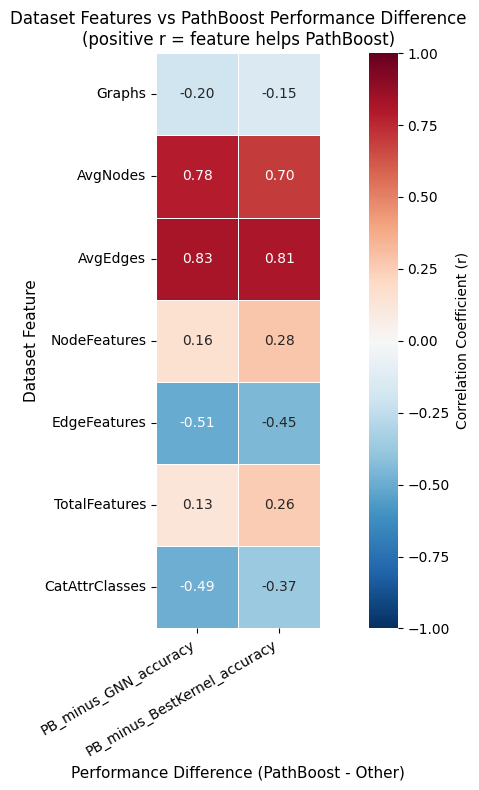


Top correlations (sorted by absolute value):

  PB - GNN accuracy:
    AvgEdges: r = +0.827 (strong, helps PB)
    AvgNodes: r = +0.782 (strong, helps PB)
    EdgeFeatures: r = -0.505 (strong, hurts PB)

  PB - BestKernel accuracy:
    AvgEdges: r = +0.813 (strong, helps PB)
    AvgNodes: r = +0.702 (strong, helps PB)
    EdgeFeatures: r = -0.450 (moderate, hurts PB)


In [13]:
# 9.1 Correlation Heatmap - Features vs Performance Difference

# Define feature columns and target columns
feature_cols = ['Graphs', 'AvgNodes', 'AvgEdges', 'NodeFeatures', 'EdgeFeatures', 'TotalFeatures', 'CatAttrClasses']
target_cols = ['PB_minus_GNN_accuracy', 'PB_minus_BestKernel_accuracy']

# Filter to columns that exist
feature_cols = [c for c in feature_cols if c in df_balanced.columns]
target_cols = [c for c in target_cols if c in df_balanced.columns]

# Calculate correlation matrix
correlation_data = df_balanced[feature_cols + target_cols].corr()
corr_subset = correlation_data.loc[feature_cols, target_cols]

# Display correlation table
print("Correlation Table: Dataset Features vs PathBoost Relative Performance")
print("=" * 75)
print("\nPositive values = feature helps PathBoost outperform competitors")
print("Negative values = feature hurts PathBoost relative to competitors\n")

# Format the table for better display
corr_display = corr_subset.copy()
corr_display.columns = [col.replace('PB_minus_', 'PB - ').replace('_', ' ') for col in corr_display.columns]
display(corr_display.round(3))

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
heatmap = sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                      vmin=-1, vmax=1, square=True, linewidths=0.5,
                      cbar_kws={'label': 'Correlation Coefficient (r)'}, ax=ax)

ax.set_title('Dataset Features vs PathBoost Performance Difference\n(positive r = feature helps PathBoost)', fontsize=12)
ax.set_xlabel('Performance Difference (PathBoost - Other)', fontsize=11)
ax.set_ylabel('Dataset Feature', fontsize=11)

# Improve readability of x-axis labels
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Print interpretation
print("\nTop correlations (sorted by absolute value):")
for target in target_cols:
    print(f"\n  {target.replace('PB_minus_', 'PB - ').replace('_', ' ')}:")
    sorted_corr = corr_subset[target].sort_values(key=abs, ascending=False)
    for feat, corr in sorted_corr.head(3).items():
        direction = "helps PB" if corr > 0 else "hurts PB"
        strength = "strong" if abs(corr) > 0.5 else "moderate" if abs(corr) > 0.3 else "weak"
        print(f"    {feat}: r = {corr:+.3f} ({strength}, {direction})")

### 9.2 Scatter Plots for Top Correlations (Relative Performance)

Visualize the strongest feature-performance relationships with trend lines.

These plots show how dataset features correlate with PathBoost's **relative advantage** over other methods (difference columns).

**Legend:**
- **r** = Pearson correlation coefficient (-1 to +1). Measures linear relationship strength.
- **p** = p-value. If p < 0.05, the correlation is statistically significant.

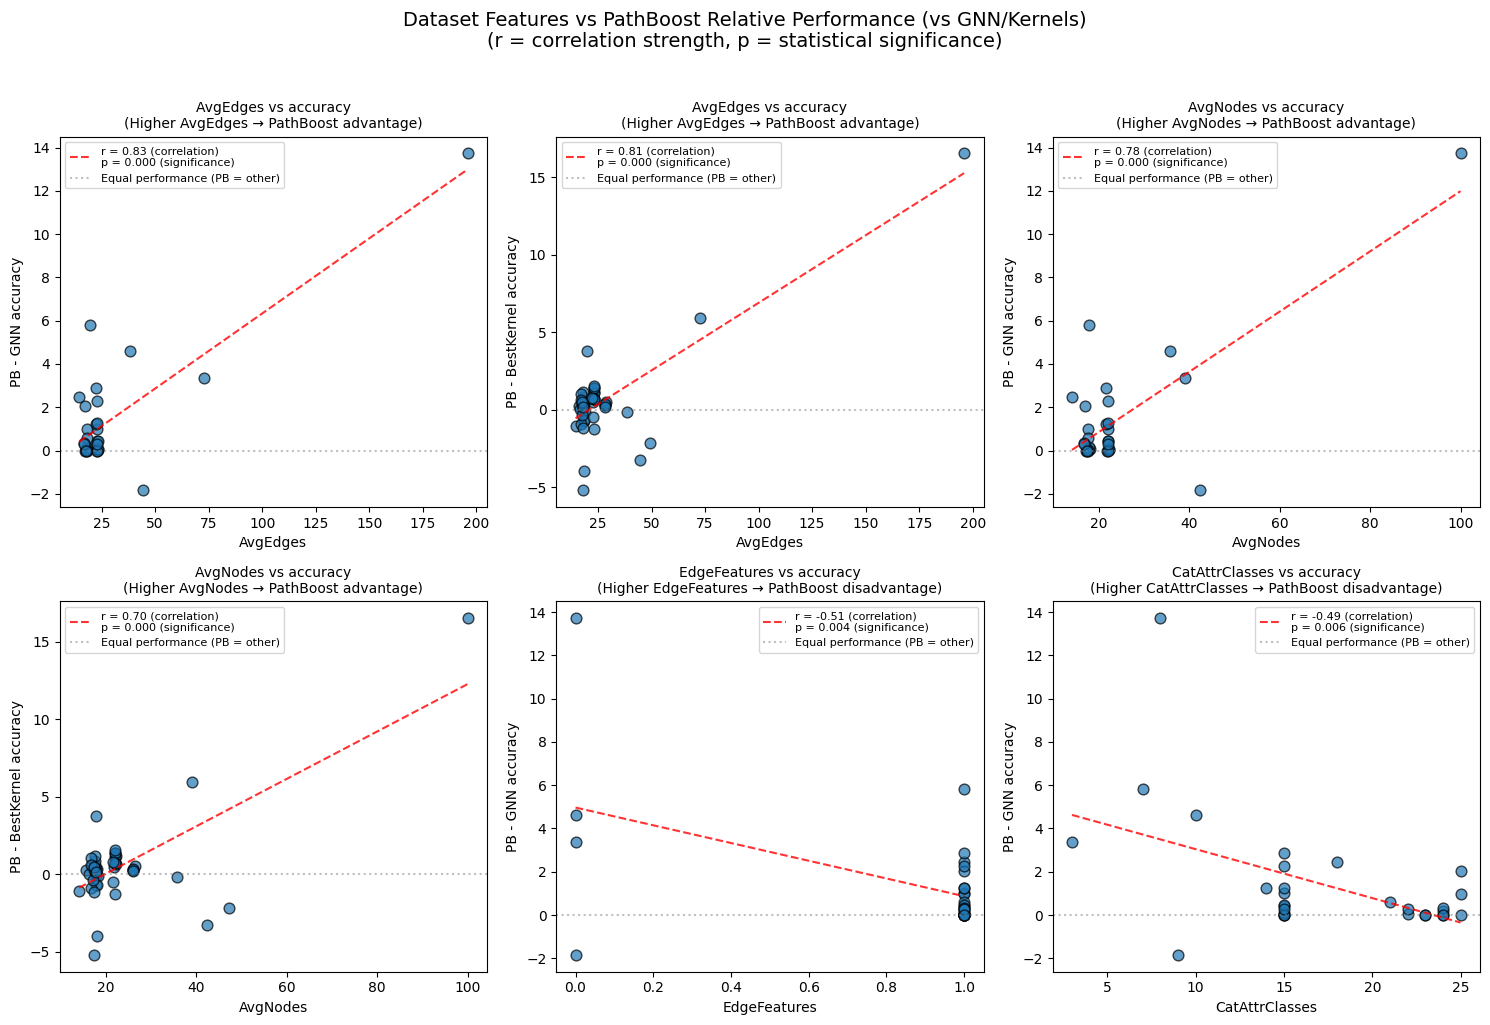

In [14]:
# 9.2 Scatter Plots for Top Correlations (Relative Performance)
from scipy import stats

# Get top 6 feature-target correlations by absolute value
all_correlations = []
for target in target_cols:
    for feat in feature_cols:
        corr_val = corr_subset.loc[feat, target]
        if pd.notna(corr_val):
            all_correlations.append({'feature': feat, 'target': target, 'correlation': corr_val})

# Sort by absolute correlation
all_correlations = sorted(all_correlations, key=lambda x: abs(x['correlation']), reverse=True)
top_correlations = all_correlations[:6]  # Top 6 for 2x3 grid

# Create scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, corr_info in enumerate(top_correlations):
    ax = axes[idx]
    feat = corr_info['feature']
    target = corr_info['target']
    corr_val = corr_info['correlation']
    
    # Get data for this pair
    plot_data = df_balanced[[feat, target, 'Dataset']].dropna()
    if len(plot_data) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Convert to numpy arrays and ensure float type
    x = plot_data[feat].astype(float).values
    y = plot_data[target].astype(float).values
    
    # Check for constant values (can't compute regression)
    if np.std(x) == 0 or np.std(y) == 0:
        ax.scatter(x, y, alpha=0.7, s=60, edgecolors='black')
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel(target.replace('PB_minus_', 'PB - ').replace('_', ' '), fontsize=10)
        ax.set_title(f'{feat} vs {target.split("_")[-1]}\n(Constant values - no trend)', fontsize=10)
        continue
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.7, s=60, edgecolors='black')
    
    # Add trend line with error handling
    try:
        result = stats.linregress(x, y)
        line_x = np.array([x.min(), x.max()])
        line_y = result.slope * line_x + result.intercept
        ax.plot(line_x, line_y, 'r--', alpha=0.8, 
               label=f'r = {corr_val:.2f} (correlation)\np = {result.pvalue:.3f} (significance)')
    except Exception as e:
        # If regression fails, just show correlation without trend line
        ax.text(0.05, 0.95, f'r = {corr_val:.2f}', transform=ax.transAxes, fontsize=9, va='top')
    
    # Add horizontal line at 0 (equal performance)
    ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5, label='Equal performance (PB = other)')
    
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel(target.replace('PB_minus_', 'PB - ').replace('_', ' '), fontsize=10)
    ax.legend(fontsize=8, loc='best')
    
    # Title with interpretation
    if corr_val > 0:
        ax.set_title(f'{feat} vs {target.split("_")[-1]}\n(Higher {feat} → PathBoost advantage)', fontsize=10)
    else:
        ax.set_title(f'{feat} vs {target.split("_")[-1]}\n(Higher {feat} → PathBoost disadvantage)', fontsize=10)

# Hide unused axes
for idx in range(len(top_correlations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Dataset Features vs PathBoost Relative Performance (vs GNN/Kernels)\n(r = correlation strength, p = statistical significance)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Scatter Plots for Absolute PathBoost Performance

Now we look at which dataset features correlate with PathBoost's **absolute accuracy and F1 score** (not relative to other methods).

**Legend:**
- **r** = Pearson correlation coefficient (-1 to +1). Measures linear relationship strength:
  - r ≈ +1: strong positive correlation (as feature increases, performance increases)
  - r ≈ -1: strong negative correlation (as feature increases, performance decreases)
  - r ≈ 0: no linear relationship
- **p** = p-value. Statistical significance of the correlation:
  - p < 0.05: correlation is statistically significant
  - p ≥ 0.05: correlation may be due to chance

Correlation Table: Dataset Features vs Absolute PathBoost Performance

Positive values = higher feature value → better PathBoost performance
Negative values = higher feature value → worse PathBoost performance



Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)


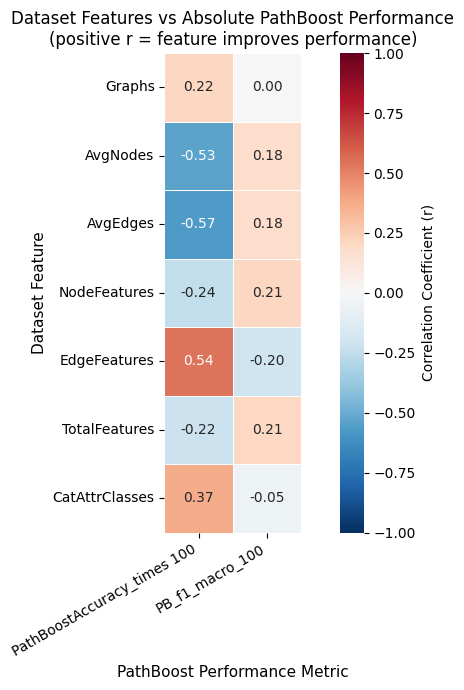


Top correlations (sorted by absolute value):

  PathBoost Accuracy:
    AvgEdges: r = -0.568 (strong, higher is worse)
    EdgeFeatures: r = +0.543 (strong, higher is better)
    AvgNodes: r = -0.531 (strong, higher is worse)

  PathBoost F1 Macro:
    NodeFeatures: r = +0.211 (weak, higher is better)
    TotalFeatures: r = +0.210 (weak, higher is better)
    EdgeFeatures: r = -0.196 (weak, higher is worse)


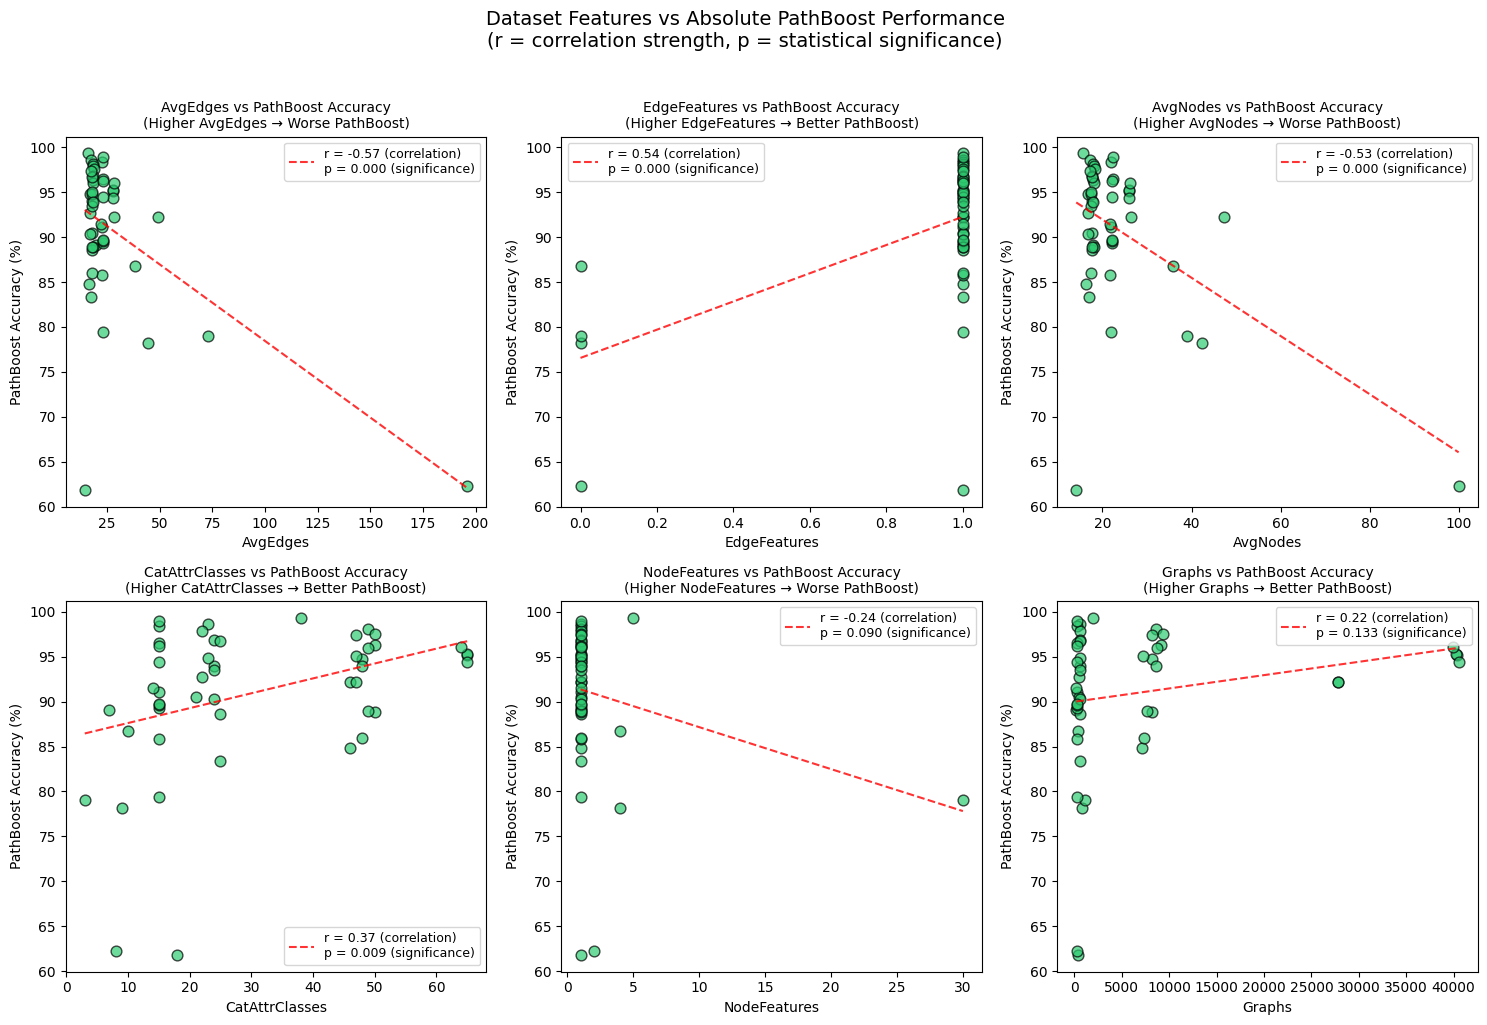

In [15]:
    # 9.3 Scatter Plots for Absolute PathBoost Performance

# Define absolute performance columns
absolute_perf_cols = ['PathBoostAccuracy_times 100']
if 'PB_f1_macro_100' in df_balanced.columns:
    absolute_perf_cols.append('PB_f1_macro_100')
elif 'PB_f1_macro' in df_balanced.columns:
    # Create scaled version if not exists
    df_balanced['PB_f1_macro_100'] = df_balanced['PB_f1_macro'] * 100
    absolute_perf_cols.append('PB_f1_macro_100')

# Calculate correlation matrix for absolute performance
corr_abs = df_balanced[feature_cols + absolute_perf_cols].corr()
corr_abs_subset = corr_abs.loc[feature_cols, absolute_perf_cols]

# Display correlation table
print("Correlation Table: Dataset Features vs Absolute PathBoost Performance")
print("=" * 75)
print("\nPositive values = higher feature value → better PathBoost performance")
print("Negative values = higher feature value → worse PathBoost performance\n")

# Format the table for better display
corr_abs_display = corr_abs_subset.copy()
corr_abs_display.columns = ['PathBoost Accuracy' if 'Accuracy' in col else 'PathBoost F1 Macro' for col in corr_abs_display.columns]
display(corr_abs_display.round(3))

# Create heatmap for absolute performance
fig, ax = plt.subplots(figsize=(8, 7))
heatmap = sns.heatmap(corr_abs_subset, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                      vmin=-1, vmax=1, square=True, linewidths=0.5,
                      cbar_kws={'label': 'Correlation Coefficient (r)'}, ax=ax)

ax.set_title('Dataset Features vs Absolute PathBoost Performance\n(positive r = feature improves performance)', fontsize=12)
ax.set_xlabel('PathBoost Performance Metric', fontsize=11)
ax.set_ylabel('Dataset Feature', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Calculate correlations for absolute performance (for scatter plots)
abs_correlations = []
for perf_col in absolute_perf_cols:
    for feat in feature_cols:
        valid_data = df_balanced[[feat, perf_col]].dropna()
        if len(valid_data) >= 3:
            corr = valid_data[feat].corr(valid_data[perf_col])
            if pd.notna(corr):
                abs_correlations.append({'feature': feat, 'target': perf_col, 'correlation': corr})

# Sort by absolute correlation
abs_correlations = sorted(abs_correlations, key=lambda x: abs(x['correlation']), reverse=True)

# Print correlation summary
print("\nTop correlations (sorted by absolute value):")
for perf_col in absolute_perf_cols:
    perf_name = 'PathBoost Accuracy' if 'Accuracy' in perf_col else 'PathBoost F1 Macro'
    print(f"\n  {perf_name}:")
    perf_corrs = [c for c in abs_correlations if c['target'] == perf_col]
    for c in sorted(perf_corrs, key=lambda x: abs(x['correlation']), reverse=True)[:3]:
        direction = "higher is better" if c['correlation'] > 0 else "higher is worse"
        strength = "strong" if abs(c['correlation']) > 0.5 else "moderate" if abs(c['correlation']) > 0.3 else "weak"
        print(f"    {c['feature']}: r = {c['correlation']:+.3f} ({strength}, {direction})")

# Create scatter plots for top 6 correlations
top_abs_correlations = abs_correlations[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, corr_info in enumerate(top_abs_correlations):
    ax = axes[idx]
    feat = corr_info['feature']
    target = corr_info['target']
    corr_val = corr_info['correlation']
    
    # Get data for this pair
    plot_data = df_balanced[[feat, target, 'Dataset']].dropna()
    if len(plot_data) < 3:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center', transform=ax.transAxes)
        continue
    
    # Convert to numpy arrays
    x = plot_data[feat].astype(float).values
    y = plot_data[target].astype(float).values
    
    # Scatter plot
    ax.scatter(x, y, alpha=0.7, s=60, edgecolors='black', c='#2ecc71')
    
    # Add trend line with error handling
    if np.std(x) > 0 and np.std(y) > 0:
        try:
            result = stats.linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = result.slope * line_x + result.intercept
            ax.plot(line_x, line_y, 'r--', alpha=0.8, 
                   label=f'r = {corr_val:.2f} (correlation)\np = {result.pvalue:.3f} (significance)')
        except Exception:
            ax.text(0.05, 0.95, f'r = {corr_val:.2f}', transform=ax.transAxes, fontsize=9, va='top')
    
    ax.set_xlabel(feat, fontsize=10)
    
    # Cleaner y-axis label
    y_label = 'PathBoost Accuracy (%)' if 'Accuracy' in target else 'PathBoost F1 Macro (%)'
    ax.set_ylabel(y_label, fontsize=10)
    ax.legend(fontsize=9, loc='best')
    
    # Title with interpretation
    if corr_val > 0:
        ax.set_title(f'{feat} vs {y_label.split("(")[0].strip()}\n(Higher {feat} → Better PathBoost)', fontsize=10)
    else:
        ax.set_title(f'{feat} vs {y_label.split("(")[0].strip()}\n(Higher {feat} → Worse PathBoost)', fontsize=10)

# Hide unused axes
for idx in range(len(top_abs_correlations), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Dataset Features vs Absolute PathBoost Performance\n(r = correlation strength, p = statistical significance)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. F1 Macro Comparison

F1 Macro is a better metric than accuracy for imbalanced datasets since it weighs all classes equally.

Compare PathBoost F1 Macro against GNN F1 Macro (kernel methods don't report F1).

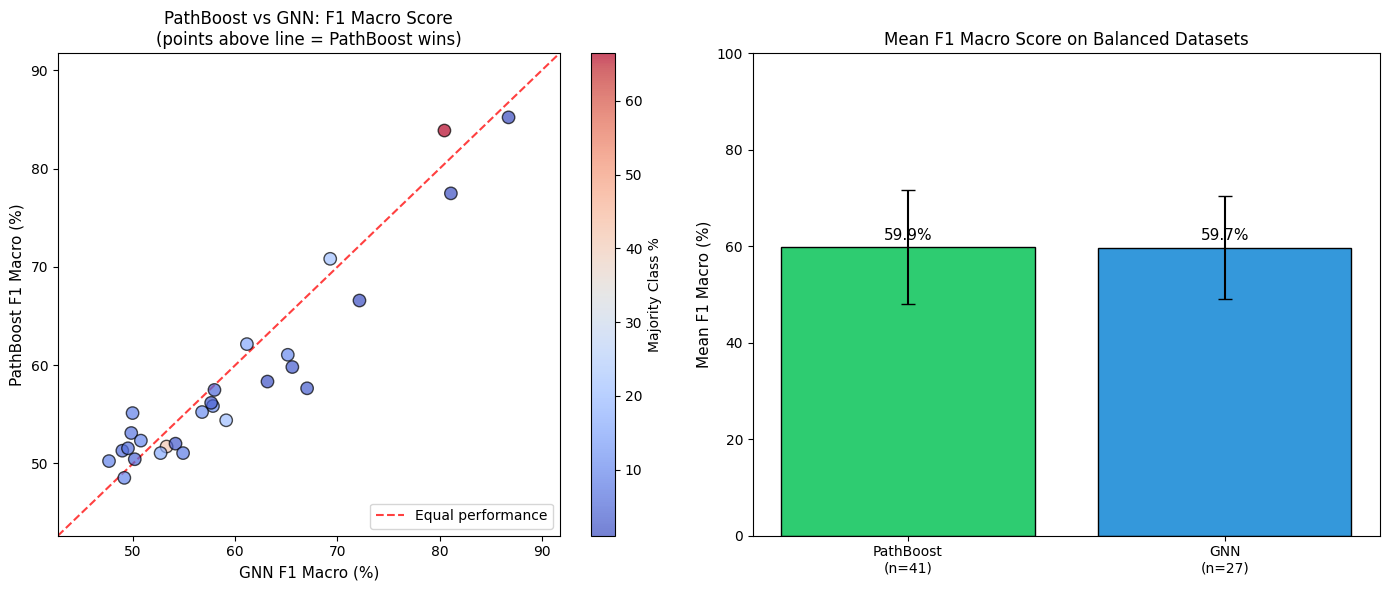


F1 Macro Summary:
  PathBoost: mean=59.87%, std=11.83%
  GNN: mean=59.70%, std=10.75%
  Datasets with both scores: 27


In [16]:
# 10.1 F1 Macro Scatter Plot - PathBoost vs GNN

# Check if F1 macro columns exist
if 'PB_f1_macro_100' in df_balanced.columns and 'GNN_f1_macro_100' in df_balanced.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Scatter plot: F1 Macro comparison
    ax1 = axes[0]
    df_f1 = df_balanced[['PB_f1_macro_100', 'GNN_f1_macro_100', 'Dataset', 'fist_class_percentage']].dropna()
    
    if len(df_f1) > 0:
        scatter = ax1.scatter(df_f1['GNN_f1_macro_100'], df_f1['PB_f1_macro_100'],
                              c=df_f1['fist_class_percentage'], cmap='coolwarm', 
                              s=80, alpha=0.7, edgecolors='black')
        
        # Diagonal reference line
        lims = [min(df_f1['GNN_f1_macro_100'].min(), df_f1['PB_f1_macro_100'].min()) - 5,
                max(df_f1['GNN_f1_macro_100'].max(), df_f1['PB_f1_macro_100'].max()) + 5]
        ax1.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Equal performance')
        ax1.set_xlim(lims)
        ax1.set_ylim(lims)
        
        ax1.set_xlabel('GNN F1 Macro (%)', fontsize=11)
        ax1.set_ylabel('PathBoost F1 Macro (%)', fontsize=11)
        ax1.set_title('PathBoost vs GNN: F1 Macro Score\n(points above line = PathBoost wins)', fontsize=12)
        ax1.legend(loc='lower right')
        plt.colorbar(scatter, ax=ax1, label='Majority Class %')
        
        # Annotate notable datasets
        for idx, row in df_f1.iterrows():
            if abs(row['PB_f1_macro_100'] - row['GNN_f1_macro_100']) > 10:
                ax1.annotate(row['Dataset'], 
                            (row['GNN_f1_macro_100'], row['PB_f1_macro_100']),
                            fontsize=8, alpha=0.7)
    
    # Bar chart: Mean F1 Macro
    ax2 = axes[1]
    f1_means = {
        'PathBoost': df_balanced['PB_f1_macro_100'].dropna().mean(),
        'GNN': df_balanced['GNN_f1_macro_100'].dropna().mean()
    }
    f1_stds = {
        'PathBoost': df_balanced['PB_f1_macro_100'].dropna().std(),
        'GNN': df_balanced['GNN_f1_macro_100'].dropna().std()
    }
    
    x_pos = np.arange(2)
    bars = ax2.bar(x_pos, list(f1_means.values()), yerr=list(f1_stds.values()), 
                   capsize=5, color=['#2ecc71', '#3498db'], edgecolor='black')
    ax2.set_ylabel('Mean F1 Macro (%)', fontsize=11)
    ax2.set_title('Mean F1 Macro Score on Balanced Datasets', fontsize=12)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'PathBoost\n(n={len(df_balanced["PB_f1_macro_100"].dropna())})',
                         f'GNN\n(n={len(df_balanced["GNN_f1_macro_100"].dropna())})'])
    ax2.set_ylim([0, 100])
    
    # Add value labels
    for bar, mean in zip(bars, f1_means.values()):
        ax2.annotate(f'{mean:.1f}%', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\nF1 Macro Summary:")
    print(f"  PathBoost: mean={f1_means['PathBoost']:.2f}%, std={f1_stds['PathBoost']:.2f}%")
    print(f"  GNN: mean={f1_means['GNN']:.2f}%, std={f1_stds['GNN']:.2f}%")
    print(f"  Datasets with both scores: {len(df_f1)}")
else:
    print("F1 Macro columns not available for comparison.")

Correlation: Dataset Features vs F1 Macro Difference (PathBoost - GNN)
  NodeFeatures        : +0.159 (PathBoost benefits from higher values)
  EdgeFeatures        : -0.159 (GNN benefits from higher values)
  TotalFeatures       : +0.159 (PathBoost benefits from higher values)
  CatAttrClasses      : -0.078 (GNN benefits from higher values)
  Graphs              : +0.062 (PathBoost benefits from higher values)
  AvgEdges            : +0.039 (PathBoost benefits from higher values)
  AvgNodes            : +0.021 (PathBoost benefits from higher values)


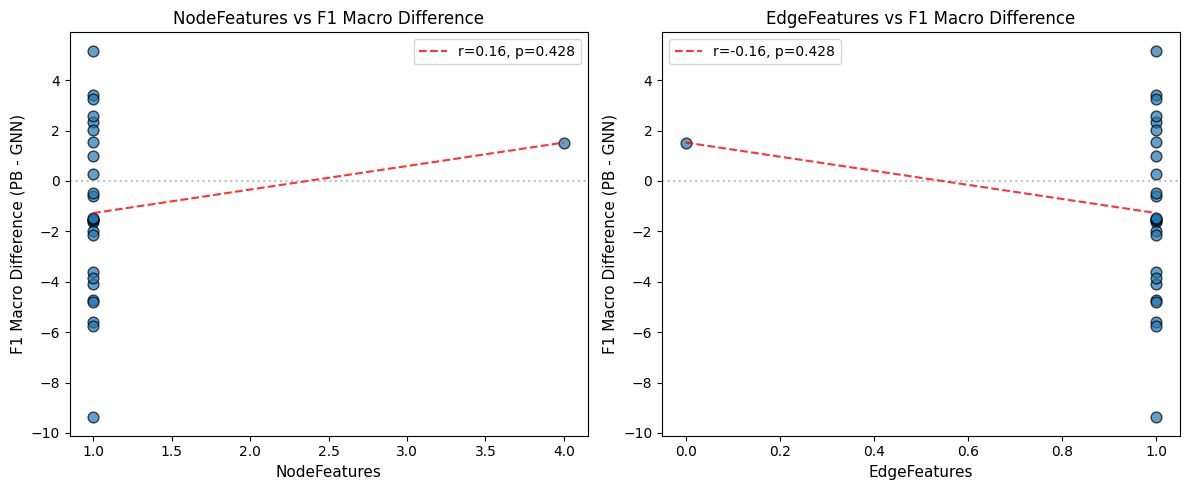

In [17]:
# 10.2 F1 Macro Correlation with Dataset Features

if 'PB_minus_GNN_f1_macro' in df_balanced.columns:
    # Calculate correlations between F1 difference and dataset features
    f1_correlations = {}
    for feat in feature_cols:
        valid_data = df_balanced[[feat, 'PB_minus_GNN_f1_macro']].dropna()
        if len(valid_data) >= 3:
            corr = valid_data[feat].corr(valid_data['PB_minus_GNN_f1_macro'])
            f1_correlations[feat] = corr
    
    if f1_correlations:
        # Sort by absolute correlation
        sorted_corrs = sorted(f1_correlations.items(), key=lambda x: abs(x[1]), reverse=True)
        
        print("Correlation: Dataset Features vs F1 Macro Difference (PathBoost - GNN)")
        print("=" * 65)
        for feat, corr in sorted_corrs:
            direction = "PathBoost benefits" if corr > 0 else "GNN benefits"
            print(f"  {feat:20s}: {corr:+.3f} ({direction} from higher values)")
        
        # Visualize top 2 correlations
        if len(sorted_corrs) >= 2:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            
            for idx, (feat, corr) in enumerate(sorted_corrs[:2]):
                ax = axes[idx]
                plot_data = df_balanced[[feat, 'PB_minus_GNN_f1_macro']].dropna()
                
                # Convert to numpy arrays and ensure float type
                x_vals = plot_data[feat].astype(float).values
                y_vals = plot_data['PB_minus_GNN_f1_macro'].astype(float).values
                
                ax.scatter(x_vals, y_vals, alpha=0.7, s=60, edgecolors='black')
                
                # Trend line with error handling
                if np.std(x_vals) > 0 and np.std(y_vals) > 0:
                    try:
                        result = stats.linregress(x_vals, y_vals)
                        line_x = np.array([x_vals.min(), x_vals.max()])
                        line_y = result.slope * line_x + result.intercept
                        ax.plot(line_x, line_y, 'r--', alpha=0.8, label=f'r={corr:.2f}, p={result.pvalue:.3f}')
                    except Exception:
                        ax.text(0.05, 0.95, f'r={corr:.2f}', transform=ax.transAxes, fontsize=9, va='top')
                
                ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
                ax.set_xlabel(feat, fontsize=11)
                ax.set_ylabel('F1 Macro Difference (PB - GNN)', fontsize=11)
                ax.set_title(f'{feat} vs F1 Macro Difference', fontsize=12)
                ax.legend()
            
            plt.tight_layout()
            plt.show()
else:
    print("F1 Macro difference column not available.")

### 10.3 F1 Macro vs Dataset Imbalance

Analyze how F1 Macro scores relate to class imbalance. 

**Hypothesis:** F1 Macro should be more robust to imbalance than accuracy, but we may still see performance degradation on highly imbalanced datasets.

Correlation: F1 Macro Score vs Class Imbalance (fist_class_percentage)

Higher fist_class_percentage = more imbalanced dataset
(50% = perfectly balanced, 100% = completely imbalanced)

PathBoost F1 Macro vs Imbalance: r = -0.038 (n=44)
GNN F1 Macro vs Imbalance:       r = +0.160 (n=27)
PathBoost Accuracy vs Imbalance: r = -0.869 (n=52)


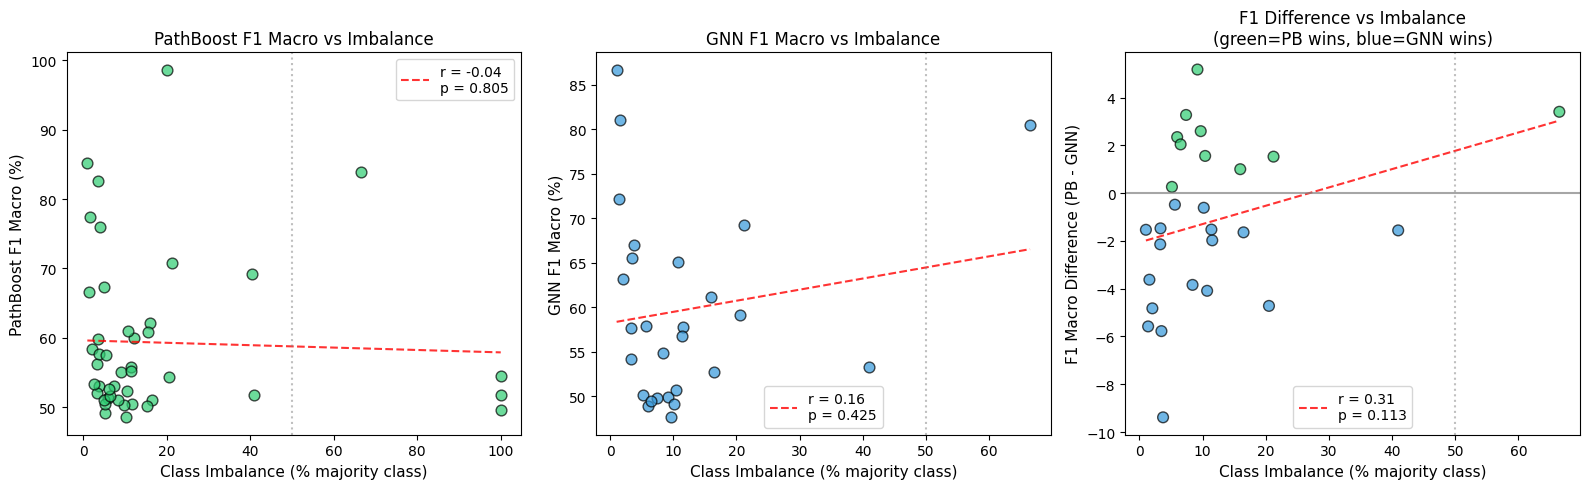


Interpretation:
  PathBoost F1 Macro: Weak correlation (r=-0.04) - relatively robust to imbalance
  GNN F1 Macro: Weak correlation (r=0.16) - relatively robust to imbalance
  PathBoost Accuracy: Negative correlation (r=-0.87) - performance drops on imbalanced data


In [18]:
# 10.3 F1 Macro vs Dataset Imbalance

# Use df_results which has fist_class_percentage
df_imbalance = df_results.copy()

# Ensure we have F1 macro columns scaled to 0-100
if 'PB_f1_macro' in df_imbalance.columns:
    df_imbalance['PB_f1_macro_100'] = df_imbalance['PB_f1_macro'] * 100
if 'GNN_f1_macro' in df_imbalance.columns:
    df_imbalance['GNN_f1_macro_100'] = df_imbalance['GNN_f1_macro'] * 100

# Calculate correlations
print("=" * 70)
print("Correlation: F1 Macro Score vs Class Imbalance (fist_class_percentage)")
print("=" * 70)
print("\nHigher fist_class_percentage = more imbalanced dataset")
print("(50% = perfectly balanced, 100% = completely imbalanced)\n")

correlations = {}
if 'PB_f1_macro_100' in df_imbalance.columns and 'fist_class_percentage' in df_imbalance.columns:
    valid = df_imbalance[['PB_f1_macro_100', 'fist_class_percentage']].dropna()
    if len(valid) >= 3:
        corr = valid['PB_f1_macro_100'].corr(valid['fist_class_percentage'])
        correlations['PathBoost F1 Macro'] = corr
        print(f"PathBoost F1 Macro vs Imbalance: r = {corr:+.3f} (n={len(valid)})")

if 'GNN_f1_macro_100' in df_imbalance.columns and 'fist_class_percentage' in df_imbalance.columns:
    valid = df_imbalance[['GNN_f1_macro_100', 'fist_class_percentage']].dropna()
    if len(valid) >= 3:
        corr = valid['GNN_f1_macro_100'].corr(valid['fist_class_percentage'])
        correlations['GNN F1 Macro'] = corr
        print(f"GNN F1 Macro vs Imbalance:       r = {corr:+.3f} (n={len(valid)})")

# Also check accuracy for comparison
if 'PathBoostAccuracy_times 100' in df_imbalance.columns and 'fist_class_percentage' in df_imbalance.columns:
    valid = df_imbalance[['PathBoostAccuracy_times 100', 'fist_class_percentage']].dropna()
    if len(valid) >= 3:
        corr = valid['PathBoostAccuracy_times 100'].corr(valid['fist_class_percentage'])
        correlations['PathBoost Accuracy'] = corr
        print(f"PathBoost Accuracy vs Imbalance: r = {corr:+.3f} (n={len(valid)})")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: PathBoost F1 Macro vs Imbalance
ax1 = axes[0]
if 'PB_f1_macro_100' in df_imbalance.columns:
    plot_data = df_imbalance[['fist_class_percentage', 'PB_f1_macro_100', 'Dataset']].dropna()
    if len(plot_data) > 0:
        x = plot_data['fist_class_percentage'].astype(float).values
        y = plot_data['PB_f1_macro_100'].astype(float).values
        
        ax1.scatter(x, y, alpha=0.7, s=60, edgecolors='black', c='#2ecc71')
        
        # Trend line
        if np.std(x) > 0 and np.std(y) > 0:
            result = stats.linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = result.slope * line_x + result.intercept
            ax1.plot(line_x, line_y, 'r--', alpha=0.8, 
                    label=f'r = {correlations.get("PathBoost F1 Macro", 0):.2f}\np = {result.pvalue:.3f}')
        
        ax1.set_xlabel('Class Imbalance (% majority class)', fontsize=11)
        ax1.set_ylabel('PathBoost F1 Macro (%)', fontsize=11)
        ax1.set_title('PathBoost F1 Macro vs Imbalance', fontsize=12)
        ax1.legend(loc='best')
        ax1.axvline(x=50, color='gray', linestyle=':', alpha=0.5, label='Balanced (50%)')

# Plot 2: GNN F1 Macro vs Imbalance
ax2 = axes[1]
if 'GNN_f1_macro_100' in df_imbalance.columns:
    plot_data = df_imbalance[['fist_class_percentage', 'GNN_f1_macro_100', 'Dataset']].dropna()
    if len(plot_data) > 0:
        x = plot_data['fist_class_percentage'].astype(float).values
        y = plot_data['GNN_f1_macro_100'].astype(float).values
        
        ax2.scatter(x, y, alpha=0.7, s=60, edgecolors='black', c='#3498db')
        
        # Trend line
        if np.std(x) > 0 and np.std(y) > 0:
            result = stats.linregress(x, y)
            line_x = np.array([x.min(), x.max()])
            line_y = result.slope * line_x + result.intercept
            ax2.plot(line_x, line_y, 'r--', alpha=0.8, 
                    label=f'r = {correlations.get("GNN F1 Macro", 0):.2f}\np = {result.pvalue:.3f}')
        
        ax2.set_xlabel('Class Imbalance (% majority class)', fontsize=11)
        ax2.set_ylabel('GNN F1 Macro (%)', fontsize=11)
        ax2.set_title('GNN F1 Macro vs Imbalance', fontsize=12)
        ax2.legend(loc='best')
        ax2.axvline(x=50, color='gray', linestyle=':', alpha=0.5)

# Plot 3: Both methods comparison (difference vs imbalance)
ax3 = axes[2]
if 'PB_f1_macro_100' in df_imbalance.columns and 'GNN_f1_macro_100' in df_imbalance.columns:
    df_imbalance['F1_diff'] = df_imbalance['PB_f1_macro_100'] - df_imbalance['GNN_f1_macro_100']
    plot_data = df_imbalance[['fist_class_percentage', 'F1_diff', 'Dataset']].dropna()
    
    if len(plot_data) > 0:
        x = plot_data['fist_class_percentage'].astype(float).values
        y = plot_data['F1_diff'].astype(float).values
        
        # Color by who wins
        colors = ['#2ecc71' if val > 0 else '#3498db' for val in y]
        ax3.scatter(x, y, alpha=0.7, s=60, edgecolors='black', c=colors)
        
        # Trend line
        if np.std(x) > 0 and np.std(y) > 0:
            result = stats.linregress(x, y)
            corr_diff = plot_data['fist_class_percentage'].corr(plot_data['F1_diff'])
            line_x = np.array([x.min(), x.max()])
            line_y = result.slope * line_x + result.intercept
            ax3.plot(line_x, line_y, 'r--', alpha=0.8, 
                    label=f'r = {corr_diff:.2f}\np = {result.pvalue:.3f}')
        
        ax3.axhline(y=0, color='gray', linestyle='-', alpha=0.7)
        ax3.axvline(x=50, color='gray', linestyle=':', alpha=0.5)
        ax3.set_xlabel('Class Imbalance (% majority class)', fontsize=11)
        ax3.set_ylabel('F1 Macro Difference (PB - GNN)', fontsize=11)
        ax3.set_title('F1 Difference vs Imbalance\n(green=PB wins, blue=GNN wins)', fontsize=12)
        ax3.legend(loc='best')

plt.tight_layout()
plt.show()

# Summary interpretation
print("\n" + "=" * 70)
print("Interpretation:")
print("=" * 70)
for name, corr in correlations.items():
    if corr < -0.3:
        print(f"  {name}: Negative correlation (r={corr:.2f}) - performance drops on imbalanced data")
    elif corr > 0.3:
        print(f"  {name}: Positive correlation (r={corr:.2f}) - performance improves on imbalanced data (unusual)")
    else:
        print(f"  {name}: Weak correlation (r={corr:.2f}) - relatively robust to imbalance")

In [19]:
## 11. Training Time Analysis

import glob

def load_timing_per_dataset(result_dirs, metric_filter='accuracy'):
    """
    Read all Performance CSVs, extract Training_Time_Mean per dataset.
    Uses the first metric matching metric_filter as the representative row.
    """
    all_dfs = []
    for pattern in result_dirs:
        for f in glob.glob(pattern):
            try:
                all_dfs.append(pd.read_csv(f))
            except Exception:
                pass
    if not all_dfs:
        return pd.DataFrame()
    
    combined = pd.concat(all_dfs, ignore_index=True)
    # For kernels the metric names are like "accuracy_WL_subtree", so use str.startswith
    combined = combined[combined['Metric'].str.startswith(metric_filter)]
    combined = combined[~combined['Training_Time_Mean'].isin(['N/A', 'TIMEOUT', 'FAILED', ''])]
    combined['Training_Time_Mean'] = pd.to_numeric(combined['Training_Time_Mean'], errors='coerce')
    combined['Training_Time_Std']  = pd.to_numeric(combined['Training_Time_Std'],  errors='coerce')
    combined = combined.dropna(subset=['Training_Time_Mean'])
    # Keep one entry per dataset (drop duplicates keeping last)
    combined = combined.sort_values('Dataset').drop_duplicates(subset='Dataset', keep='last')
    return combined[['Dataset', 'Training_Time_Mean', 'Training_Time_Std']].reset_index(drop=True)

def load_kernel_timing_per_dataset(result_dirs):
    """
    For kernels, average the per-fold time across all kernel methods per dataset.
    """
    all_dfs = []
    for pattern in result_dirs:
        for f in glob.glob(pattern):
            try:
                all_dfs.append(pd.read_csv(f))
            except Exception:
                pass
    if not all_dfs:
        return pd.DataFrame()

    combined = pd.concat(all_dfs, ignore_index=True)
    combined = combined[combined['Metric'].str.startswith('accuracy_')]
    combined = combined[~combined['Training_Time_Mean'].isin(['N/A', 'TIMEOUT', 'FAILED', ''])]
    combined['Training_Time_Mean'] = pd.to_numeric(combined['Training_Time_Mean'], errors='coerce')
    combined = combined.dropna(subset=['Training_Time_Mean'])
    # Average per-fold time across all kernel methods per dataset
    agg = combined.groupby('Dataset')['Training_Time_Mean'].mean().reset_index()
    agg.columns = ['Dataset', 'Training_Time_Mean']
    return agg

# Load timing data
pb_timing = load_timing_per_dataset(['../PathBoost_results/*.csv'])
gnn_timing = load_timing_per_dataset(['../GNN_results/*.csv'])
kernel_timing = load_kernel_timing_per_dataset(['../Kernel_results/*.csv'])

pb_timing      = pb_timing.rename(columns={'Training_Time_Mean': 'PB_Time_s',     'Training_Time_Std': 'PB_Time_Std'})
gnn_timing     = gnn_timing.rename(columns={'Training_Time_Mean': 'GNN_Time_s',    'Training_Time_Std': 'GNN_Time_Std'})
kernel_timing  = kernel_timing.rename(columns={'Training_Time_Mean': 'Kernel_Time_s'})

# Merge all
df_timing = (pb_timing[['Dataset', 'PB_Time_s']]
             .merge(gnn_timing[['Dataset', 'GNN_Time_s']], on='Dataset', how='outer')
             .merge(kernel_timing[['Dataset', 'Kernel_Time_s']], on='Dataset', how='outer')
             .sort_values('Dataset').reset_index(drop=True))

print("=" * 80)
print("TRAINING TIME PER FOLD (seconds)")
print("=" * 80)
print("PathBoost: time for .fit() of best config | GNN: wall-clock time per config")
print("Kernel: total elapsed / 100 folds (averaged across kernel methods)\n")
display(df_timing.round(3))

print("\nSummary (mean across datasets):")
for col, label in [('PB_Time_s', 'PathBoost'), ('GNN_Time_s', 'GNN'), ('Kernel_Time_s', 'Kernel')]:
    if col in df_timing.columns:
        vals = df_timing[col].dropna()
        if len(vals):
            print(f"  {label}: mean={vals.mean():.2f}s, median={vals.median():.2f}s  (n={len(vals)} datasets)")

TRAINING TIME PER FOLD (seconds)
PathBoost: time for .fit() of best config | GNN: wall-clock time per config
Kernel: total elapsed / 100 folds (averaged across kernel methods)



Loading ITables v2.6.2 from the init_notebook_mode cell... (need help?)



Summary (mean across datasets):
  PathBoost: mean=21.72s, median=19.51s  (n=34 datasets)
  GNN: mean=7.72s, median=6.21s  (n=40 datasets)


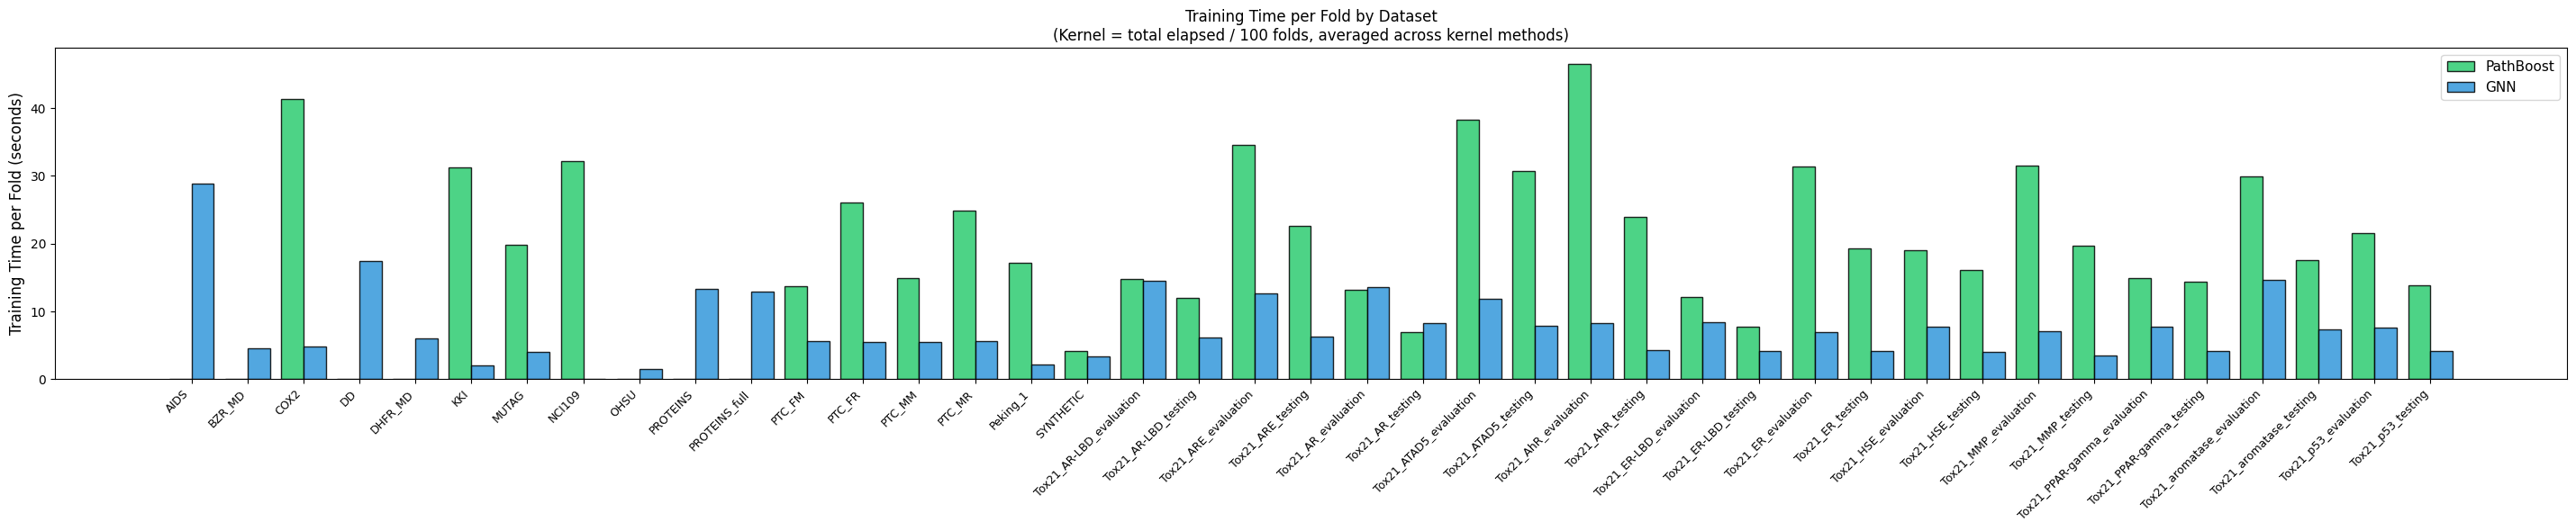

In [20]:
# 11.1 Bar Chart - Training Time per Dataset (PathBoost vs GNN vs Kernel)

plot_cols = {'PB_Time_s': ('PathBoost', '#2ecc71'), 'GNN_Time_s': ('GNN', '#3498db'), 'Kernel_Time_s': ('Kernel', '#9b59b6')}
available = {k: v for k, v in plot_cols.items() if k in df_timing.columns and df_timing[k].notna().any()}

df_plot = df_timing.dropna(subset=list(available.keys()), how='all').copy()

if len(df_plot) > 0:
    datasets = df_plot['Dataset'].values
    x = np.arange(len(datasets))
    n_methods = len(available)
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(max(12, len(datasets) * 0.7), 6))

    for i, (col, (label, color)) in enumerate(available.items()):
        offset = (i - n_methods / 2 + 0.5) * width
        ax.bar(x + offset, df_plot[col].fillna(0), width,
               label=label, color=color, edgecolor='black', alpha=0.85)

    ax.set_ylabel('Training Time per Fold (seconds)', fontsize=12)
    ax.set_title('Training Time per Fold by Dataset\n(Kernel = total elapsed / 100 folds, averaged across kernel methods)', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=11)
    plt.tight_layout()
    plt.show()






